# WGCNA
weighted gene co-expression network analysis

with the new reference genome (nov 2025 release)

# Phase 2

following [Hovrath Lab Tutorial](https://www.dropbox.com/scl/fo/4vqfiysan6rlurfo2pbnk/h?dl=0&e=1&preview=Consensus-NetworkConstruction-man.pdf&rlkey=thqg8wlpdn4spu3ihjuc1kmlu)

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(WGCNA)
library(janitor) # for row_to_names()
library(zoo)
library(ComplexHeatmap)
library(circlize)
library(reshape)
library(fastDummies) # create 0/1 factor columns
library(ape) # for read.gff
library(cowplot) # for plot_grid()

In [3]:
# important setting, cannot omit
options(stringsAsFactors = FALSE)

In [4]:
# allow multi-threading within WGCNA
enableWGCNAThreads()

Allowing parallel execution with up to 11 working processes.


## 1. structure WGCNA input

**Expected input**:
- Rows = samples
- Columns = genes (or probes/features)
- Values = numeric expression values

### A. format vst expression matrix
preferred over normalized counts

In [5]:
dataExpr <- read.csv(
  "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv"
) %>%
  t() %>%
  as.data.frame() %>%
  row_to_names(row_number = 1)

# Convert all expression values to numeric
dataExpr <- dataExpr %>%
  mutate(across(everything(), as.numeric))

head(dataExpr)

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,11.62347,9.029866,9.098889,10.15597,13.47150,9.429854,9.049141,9.538842,10.81976,9.816081,⋯,10.24157,9.853103,9.356344,9.797982,13.54487,9.237887,11.60586,10.85918,8.692987,8.631718
B1_W5_O50,11.42347,11.165142,8.848789,10.54536,13.51419,9.490282,8.712404,9.988513,10.20566,9.859329,⋯,11.05565,9.164438,9.626449,9.521790,13.30848,9.305359,11.77717,10.83431,8.886303,8.685430
B2_B5_O51,11.40884,11.566796,10.019625,10.56687,13.68474,9.402242,9.064882,9.469731,11.29838,9.937257,⋯,11.17348,10.387383,9.500313,9.610918,13.73318,9.487701,11.85089,10.59245,8.483578,8.806881
B2_C4_O40,11.27515,10.565749,8.719850,10.40631,13.52047,9.264949,8.801877,10.284625,10.28683,9.786376,⋯,10.34171,9.054824,9.507671,9.395459,13.31380,9.358034,11.38844,10.81102,8.768388,8.801877
B3_B4_O41,11.00057,11.604647,8.800497,10.49274,13.79515,9.195805,9.182063,10.169261,10.75231,9.810731,⋯,10.45009,9.092622,8.900211,9.030323,13.53080,9.765608,11.62245,10.64279,8.599502,8.800497
B3_C3_O30,10.98404,10.704805,8.700895,10.75340,13.91540,9.150586,8.987819,9.451888,10.59041,9.859582,⋯,10.50854,9.088857,9.583992,9.377320,13.31487,9.600599,11.66156,10.46238,8.483578,8.684801


### B. identify and remove genes with missing data 
genes with too many NAs or zero-counts

In [6]:
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 92 samples x 26060 genes

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

[1]    92 26060

passes! so skipping C

### C. Sample size and gene filtering

removing low-variance genes first:

```
dataExpr <- dataExpr[, apply(dataExpr, 2, var) > quantile(apply(dataExpr, 2, var), 0.25)]
dim(dataExpr) # 94 samples x 26547 genes
```

check again 

```
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 94 samples x 35396 genes
```

### D. Sample outlier detection

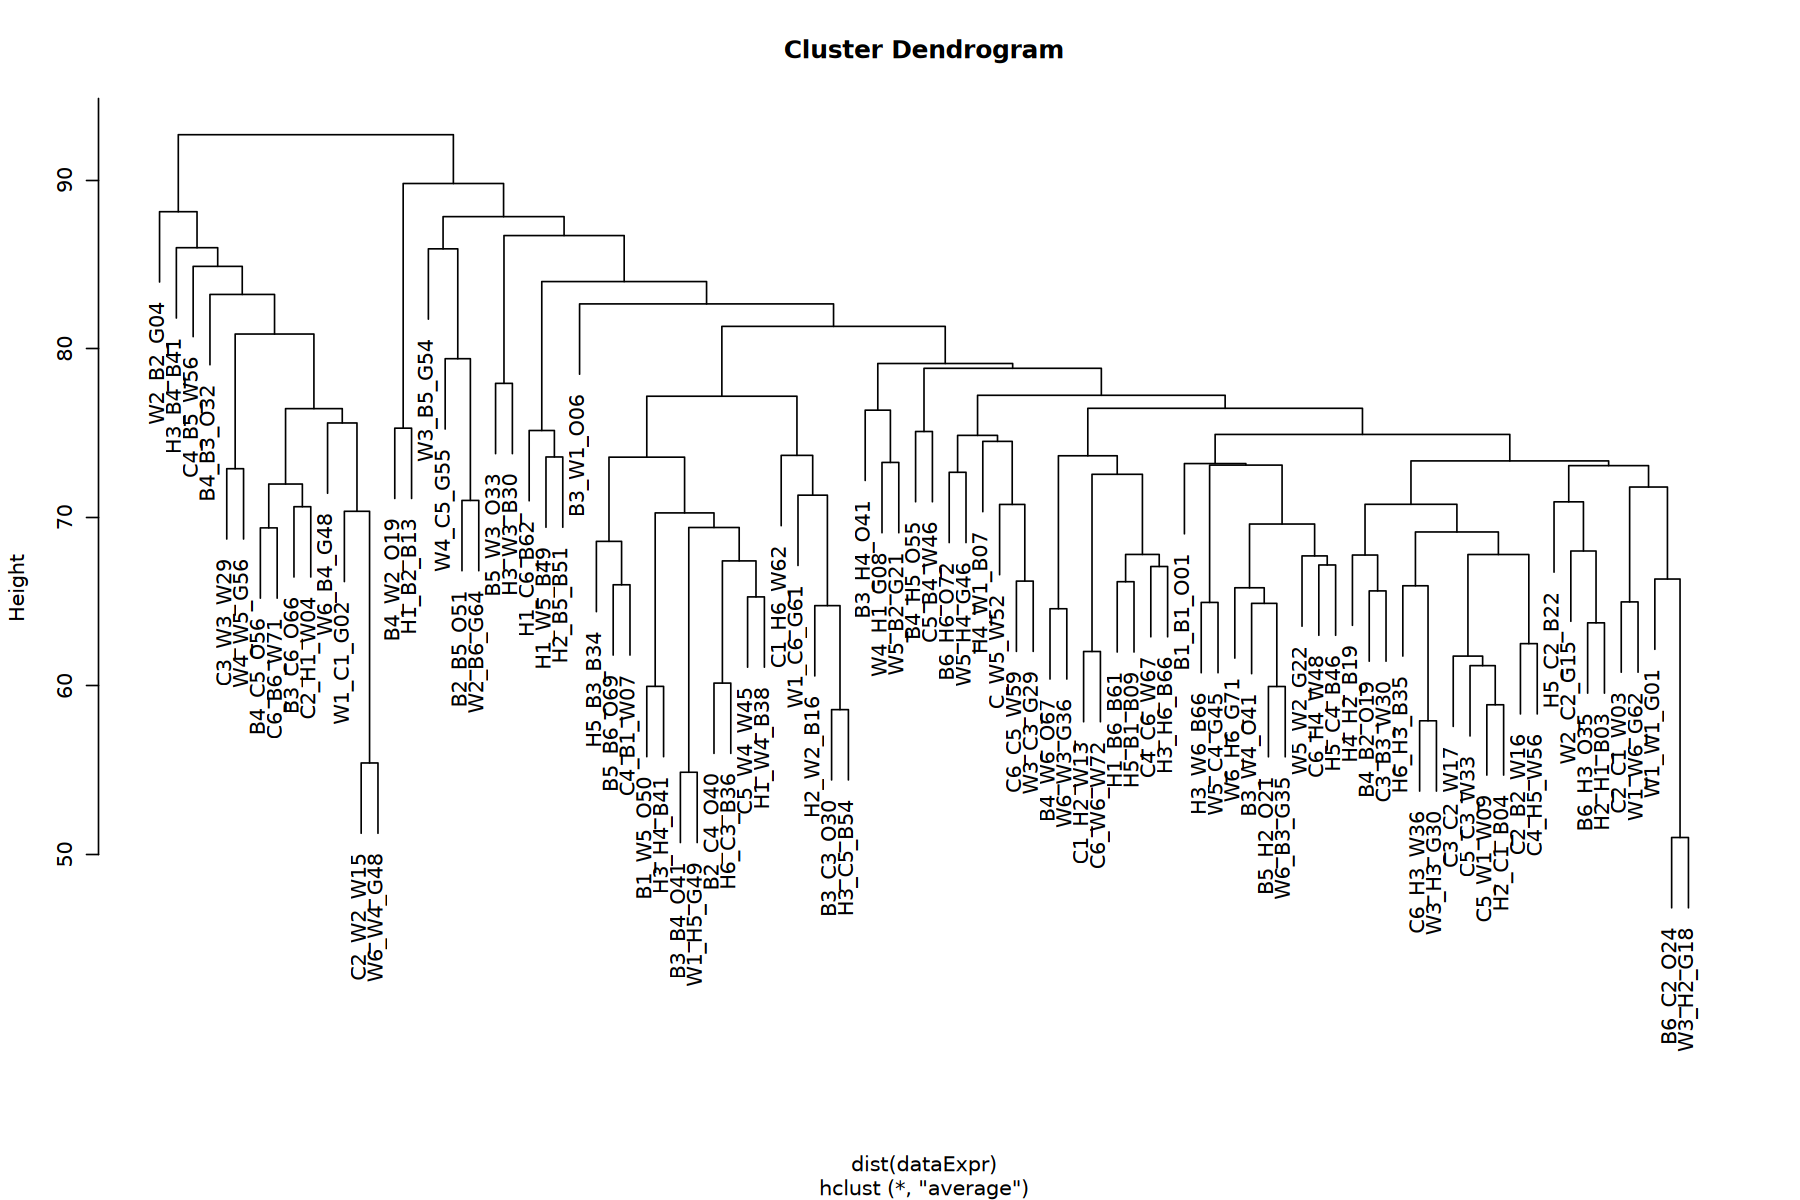

In [7]:
options(repr.plot.width = 15, repr.plot.height = 10)

sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

no obvious optical outliers to remove

### meta data
could add phenotypic data to this ...

In [8]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

### caught this below but fixing here
# fix missing rep number
rownames(dataExpr)[rownames(dataExpr) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(meta)[rownames(meta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(meta)[rownames(meta) == 'W2_B2_G04'] <- 'W2_B1_G04'

# removing same samples as dataExpr
meta <- meta[rownames(meta) %in% rownames(dataExpr), ]



head(meta)
dim(meta) # 92 samples

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 92  8

In [9]:
rownames(dataExpr)[!rownames(dataExpr) %in% rownames(meta)]

character(0)

In [10]:
rownames(dataExpr)[rownames(dataExpr) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(meta)[rownames(meta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(meta)[rownames(meta) == 'W2_B2_G04'] <- 'W2_B1_G04'

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [11]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

In [12]:
# double checking the samples in rownames are the same
all(rownames(meta) == rownames(dataExpr))

[1] TRUE

## 2. simple WGCNA network construction and module identification
start with simple, can progress to consensus if deemed necessary

In [13]:
# final QC check
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

### A. choose soft thresholding power (β)
analysis of network topology

In [14]:
powers <- c(1:20)
sft <- pickSoftThreshold(
  dataExpr,
  powerVector = powers,
  networkType = "signed",
  verbose = 5
)


pickSoftThreshold: will use block size 1716.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1716 of 26060
   ..working on genes 1717 through 3432 of 26060
   ..working on genes 3433 through 5148 of 26060
   ..working on genes 5149 through 6864 of 26060
   ..working on genes 6865 through 8580 of 26060
   ..working on genes 8581 through 10296 of 26060
   ..working on genes 10297 through 12012 of 26060
   ..working on genes 12013 through 13728 of 26060
   ..working on genes 13729 through 15444 of 26060
   ..working on genes 15445 through 17160 of 26060
   ..working on genes 17161 through 18876 of 26060
   ..working on genes 18877 through 20592 of 26060
   ..working on genes 20593 through 22308 of 26060
   ..working on genes 22309 through 24024 of 26060
   ..working on genes 24025 through 25740 of 26060
   ..working on genes 25741 through 26060 of 26060
   Power SFT.R.sq  slope truncated.R.sq  mean.k. median.k. max.k.
1      1  0.00169  -3.

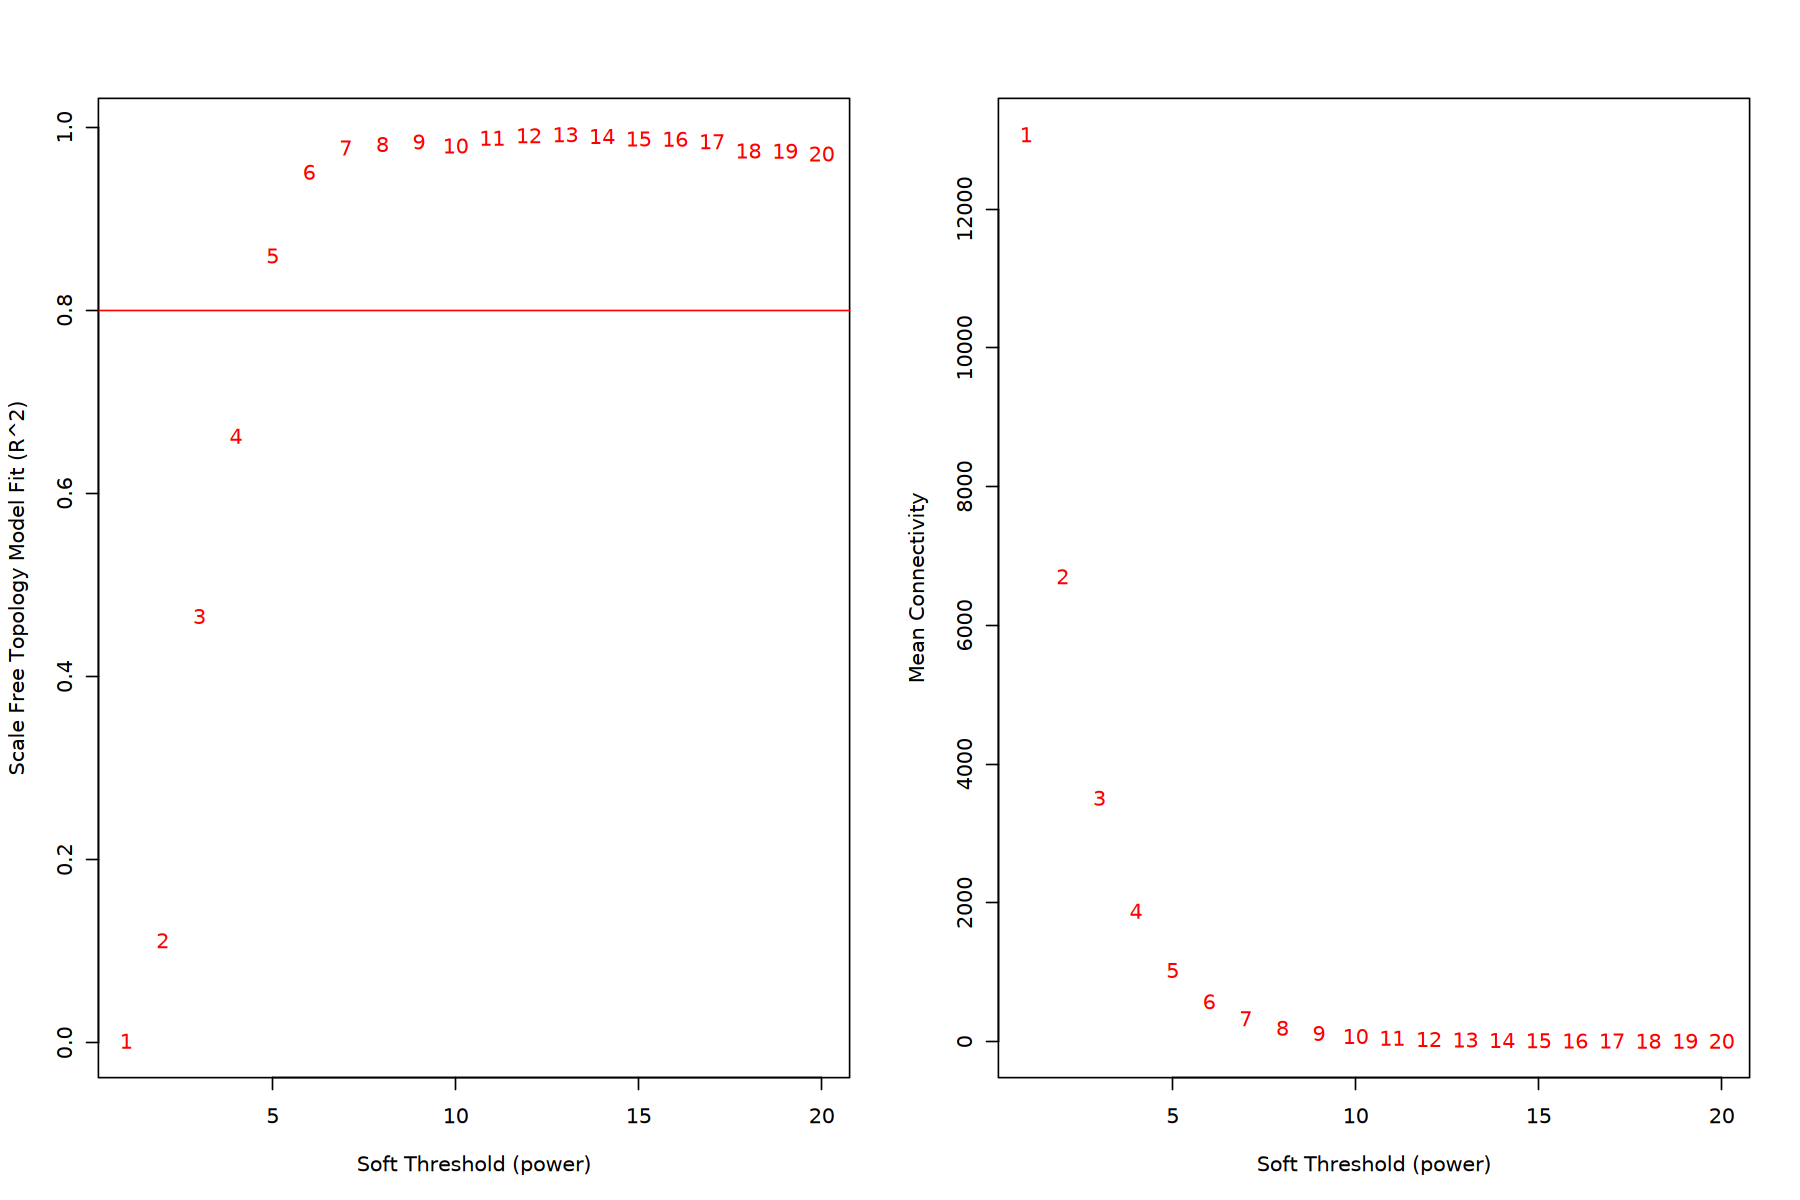

In [15]:
par(mfrow = c(1,2))
plot(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  xlab = "Soft Threshold (power)",
  ylab = "Scale Free Topology Model Fit (R^2)",
  type = "n"
)
text(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  labels = powers,
  col = "red"
)
abline(h = 0.8, col = "red")

plot(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  xlab = "Soft Threshold (power)",
  ylab = "Mean Connectivity",
  type = "n"
)
text(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  labels = powers,
  col = "red"
)


#### left plot - scale-free topology
the red line is where R^2 is 0.8 - you want the lowest power that reaches this - 6 is just above 0.8 and anything after 8 plateaus

#### right plot - mean connectivity
connectivity should not collapse to 0 - by power 8-10, the connectivity approaches 0

based on this, I think power of 5 should be appropriate

### B. co-expression similarity and adjacency

creating adjacency matrix

In [16]:
softPower <- 5

calculate co-expression adjacency using soft threshold power of 5

can do this signed or unsigned (default) - i've decided on signed but see old commits for both signed and unsigned

In [17]:
# signed
adjacency_sign <- adjacency(dataExpr, power = softPower, type = 'signed') 
head(adjacency_sign)

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
LOC144621260,1.000000000,0.189769485,0.25388691,0.008382399,0.023709028,0.021100889,0.04011751,0.04108403,0.098964315,0.03022138,⋯,0.03354579,0.04606153,0.06206099,0.08803954,0.02446783,0.003497445,0.01106460,0.0713384844,0.007240629,0.021677157
LOC144621269,0.189769485,1.000000000,0.07260524,0.040739124,0.101218489,0.006375811,0.08344178,0.03843851,0.182930817,0.09632668,⋯,0.05327620,0.03808790,0.04265341,0.04455384,0.03940091,0.021291704,0.02873371,0.0158978835,0.018744433,0.017777381
LOC111120925,0.253886910,0.072605242,1.00000000,0.031646728,0.042513127,0.026893549,0.03257533,0.05146203,0.097261544,0.03607323,⋯,0.01362543,0.03456526,0.02181632,0.01811565,0.03872384,0.017211081,0.03290938,0.0309112789,0.018026702,0.045670852
LOC144621283,0.008382399,0.040739124,0.03164673,1.000000000,0.168981351,0.005595778,0.01507265,0.02956226,0.006610188,0.03586419,⋯,0.02526684,0.02278163,0.05495807,0.04382983,0.04879303,0.089552703,0.01063284,0.0004035487,0.019513193,0.009140046
LOC144621276,0.023709028,0.101218489,0.04251313,0.168981351,1.000000000,0.003034505,0.01741859,0.03524780,0.018477409,0.05094837,⋯,0.03513534,0.02567413,0.03739476,0.02907561,0.25156594,0.245756734,0.04496481,0.0010583290,0.016835543,0.007402073
LOC111115920,0.021100889,0.006375811,0.02689355,0.005595778,0.003034505,1.000000000,0.07473026,0.07349598,0.055854213,0.02510788,⋯,0.02007920,0.03058756,0.03046178,0.05830744,0.01656463,0.012152929,0.03087822,0.1028687029,0.096878136,0.169667085


In [18]:
write.csv(data.frame(gene = rownames(adjacency_sign)), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_UniversalGeneList.csv', row.names = FALSE)

### C. Topological Overlap Matrix (TOM)
transform adjacency into TOM to minimize effects of noise and spurious associations - calculate corresponding dissimilarity

In [19]:
## SIGNED
# turn adjacency into topological overlap
TOM_sign <- TOMsimilarity(adjacency_sign)
head(TOM_sign)

# calculate dissimilarity
dissTOM_sign <- 1-TOM_sign
head(dissTOM_sign)

..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.00000000,0.12024079,0.09404131,0.03886195,0.04705353,0.04212933,0.05367419,0.04381933,0.06780638,0.05153052,⋯,0.04627673,0.05290523,0.04759848,0.05513500,0.04297701,0.03168474,0.04249362,0.04950690,0.04071695,0.04620249
0.12024079,1.00000000,0.07336977,0.06301278,0.09419587,0.03755038,0.09260350,0.05903543,0.11403856,0.09575126,⋯,0.06893147,0.06420146,0.06537994,0.06950665,0.06803838,0.05070780,0.05911320,0.04295569,0.05033003,0.04892247
0.09404131,0.07336977,1.00000000,0.04573249,0.04693398,0.04551672,0.05101814,0.05153905,0.06537190,0.05166353,⋯,0.04099722,0.05166940,0.04692806,0.04688557,0.04969861,0.03802233,0.05166408,0.04775064,0.04405010,0.05345212
0.03886195,0.06301278,0.04573249,1.00000000,0.08181299,0.03074658,0.03598729,0.03925143,0.03897413,0.04092159,⋯,0.04142886,0.03645820,0.04897404,0.03850453,0.05325542,0.06469964,0.03331075,0.02379176,0.03778022,0.03292764
0.04705353,0.09419587,0.04693398,0.08181299,1.00000000,0.02920010,0.04717042,0.04454216,0.04721275,0.05133151,⋯,0.04821391,0.04254133,0.06251348,0.04542849,0.08849272,0.09314635,0.04598175,0.02473659,0.04039886,0.03437035
0.04212933,0.03755038,0.04551672,0.03074658,0.02920010,1.00000000,0.04300234,0.04244267,0.05126234,0.03437985,⋯,0.03657629,0.04060552,0.03701053,0.04333092,0.03320044,0.03091199,0.04101411,0.05608195,0.04395531,0.04905326


0.0000000,0.8797592,0.9059587,0.9611381,0.9529465,0.9578707,0.9463258,0.9561807,0.9321936,0.9484695,⋯,0.9537233,0.9470948,0.9524015,0.9448650,0.9570230,0.9683153,0.9575064,0.9504931,0.9592830,0.9537975
0.8797592,0.0000000,0.9266302,0.9369872,0.9058041,0.9624496,0.9073965,0.9409646,0.8859614,0.9042487,⋯,0.9310685,0.9357985,0.9346201,0.9304934,0.9319616,0.9492922,0.9408868,0.9570443,0.9496700,0.9510775
0.9059587,0.9266302,0.0000000,0.9542675,0.9530660,0.9544833,0.9489819,0.9484609,0.9346281,0.9483365,⋯,0.9590028,0.9483306,0.9530719,0.9531144,0.9503014,0.9619777,0.9483359,0.9522494,0.9559499,0.9465479
0.9611381,0.9369872,0.9542675,0.0000000,0.9181870,0.9692534,0.9640127,0.9607486,0.9610259,0.9590784,⋯,0.9585711,0.9635418,0.9510260,0.9614955,0.9467446,0.9353004,0.9666892,0.9762082,0.9622198,0.9670724
0.9529465,0.9058041,0.9530660,0.9181870,0.0000000,0.9707999,0.9528296,0.9554578,0.9527873,0.9486685,⋯,0.9517861,0.9574587,0.9374865,0.9545715,0.9115073,0.9068536,0.9540182,0.9752634,0.9596011,0.9656296
0.9578707,0.9624496,0.9544833,0.9692534,0.9707999,0.0000000,0.9569977,0.9575573,0.9487377,0.9656202,⋯,0.9634237,0.9593945,0.9629895,0.9566691,0.9667996,0.9690880,0.9589859,0.9439181,0.9560447,0.9509467


### D. Call the hierarchical clustering function - plot the tree
hierarchical clustering tree (dendrogram) of genes

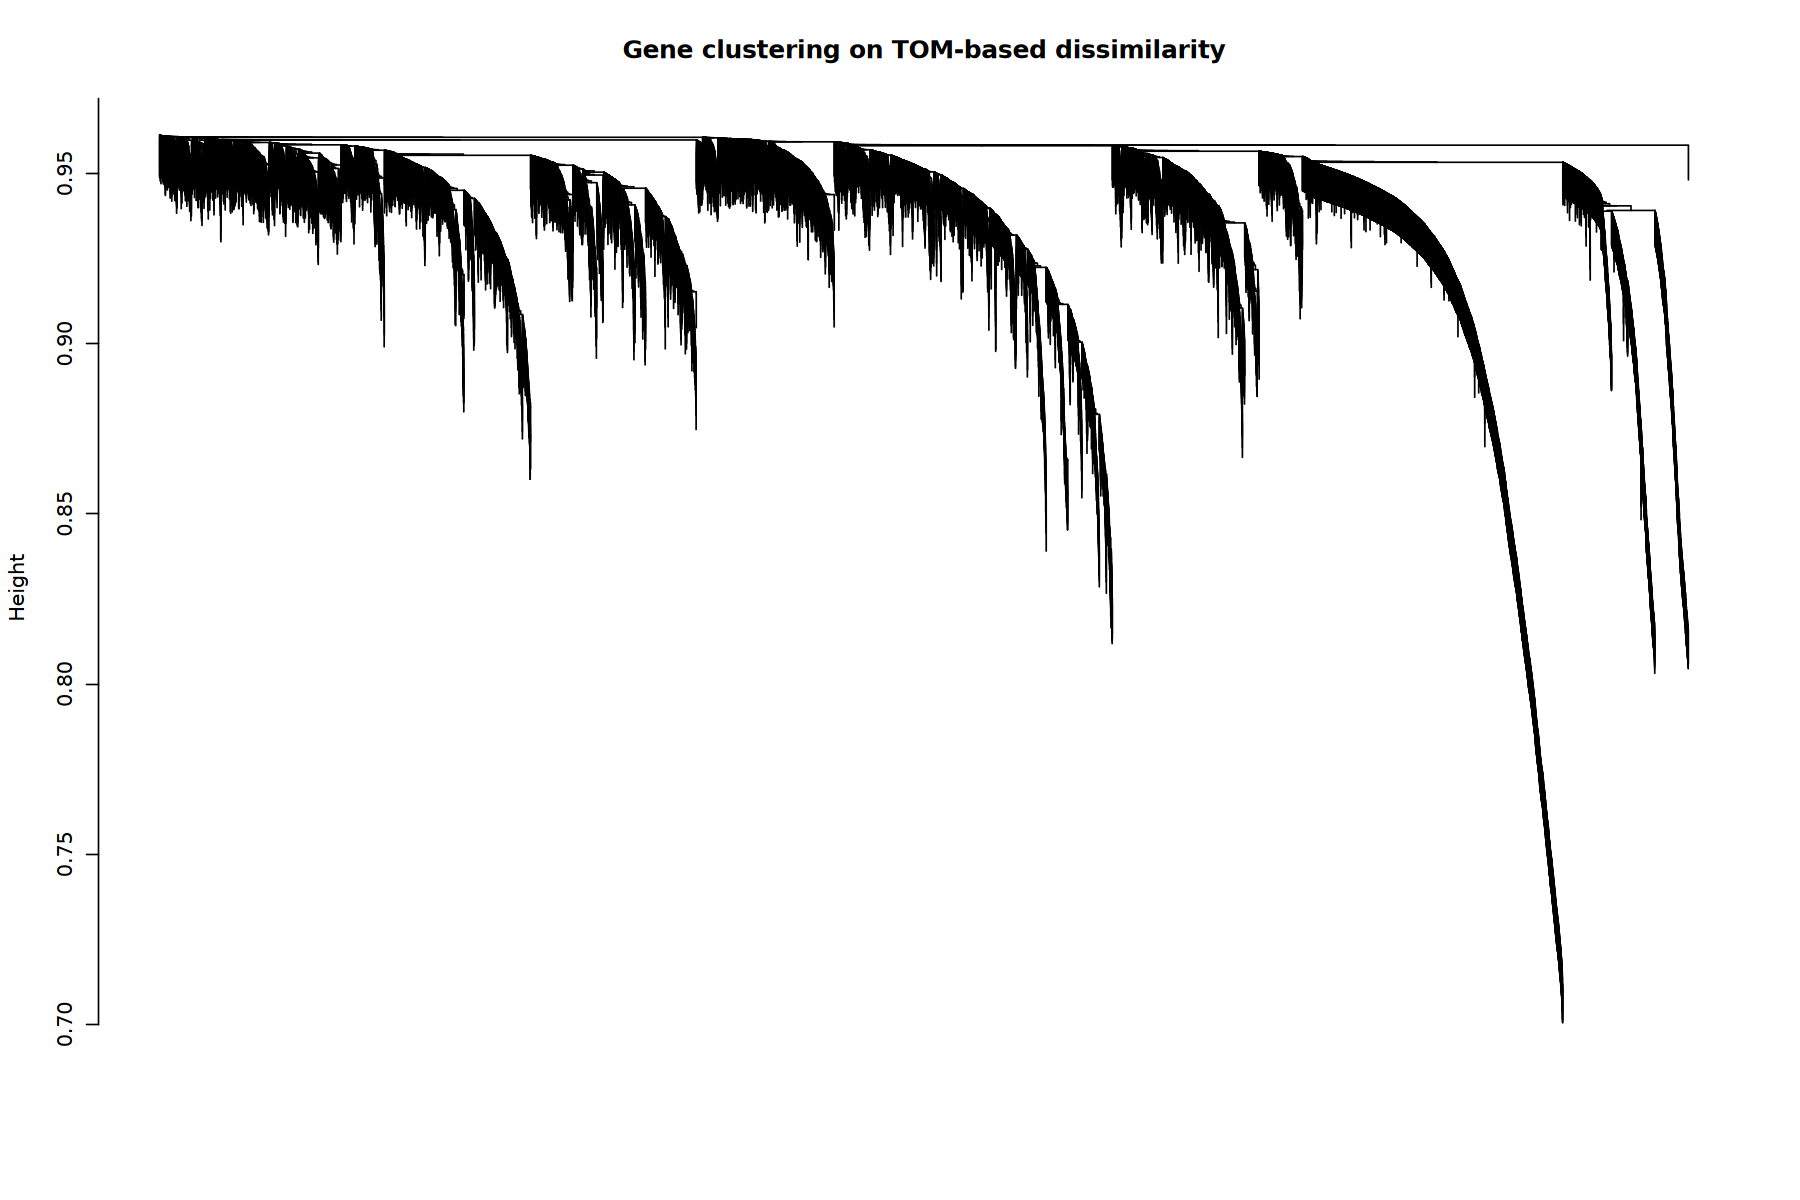

In [20]:
# call hierarchical clustering function
geneTree_sign = hclust(as.dist(dissTOM_sign), method = "average")

# plot the dendrogram
plot(geneTree_sign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)

looks like the signed adjacency matrix resulted in more distinct leafs than the unsigned matrix ...

from here on out, I'm going to use the ***signed*** correlation matrix

each leaf (short vertical line) corresponds to a gene - branches group together densely interconnected, highly co-expressed genes

module identification = cutting branches off the dendrogram

### E. module identification

set minimum module size - this is the smallest number of genes allowed to be put into a module 

then use Dynamic Tree Cut which is the default method for branch cutting and module detection

In [21]:
# would like large modules, so we set the minimum module size relatively high:
minModuleSize <- 100

## SIGNED
# Module identification using dynamic tree cut:
dynamicMods_sign <- cutreeDynamic(dendro = geneTree_sign, distM = dissTOM_sign, 
                             deepSplit = 2, pamRespectsDendro = FALSE,
                             minClusterSize = minModuleSize)
table(dynamicMods_sign) # number of genes per module

 ..cutHeight not given, setting it to 0.96  ===>  99% of the (truncated) height range in dendro.
 ..done.


dynamicMods_sign
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
4379 3544 2626 2578 2578 2287 1436 1387 1341 1117  632  535  433  401  321  257 
  17 
 208 

16 modules generated

convert numeric network to colors and plots dendrogram:

dynamicColors_sign
       black         blue        brown         cyan        green  greenyellow 
        1436         3544         2626          401         2578          632 
      grey60    lightcyan      magenta midnightblue         pink       purple 
         208          257         1341          321         1387         1117 
         red       salmon          tan    turquoise       yellow 
        2287          433          535         4379         2578 

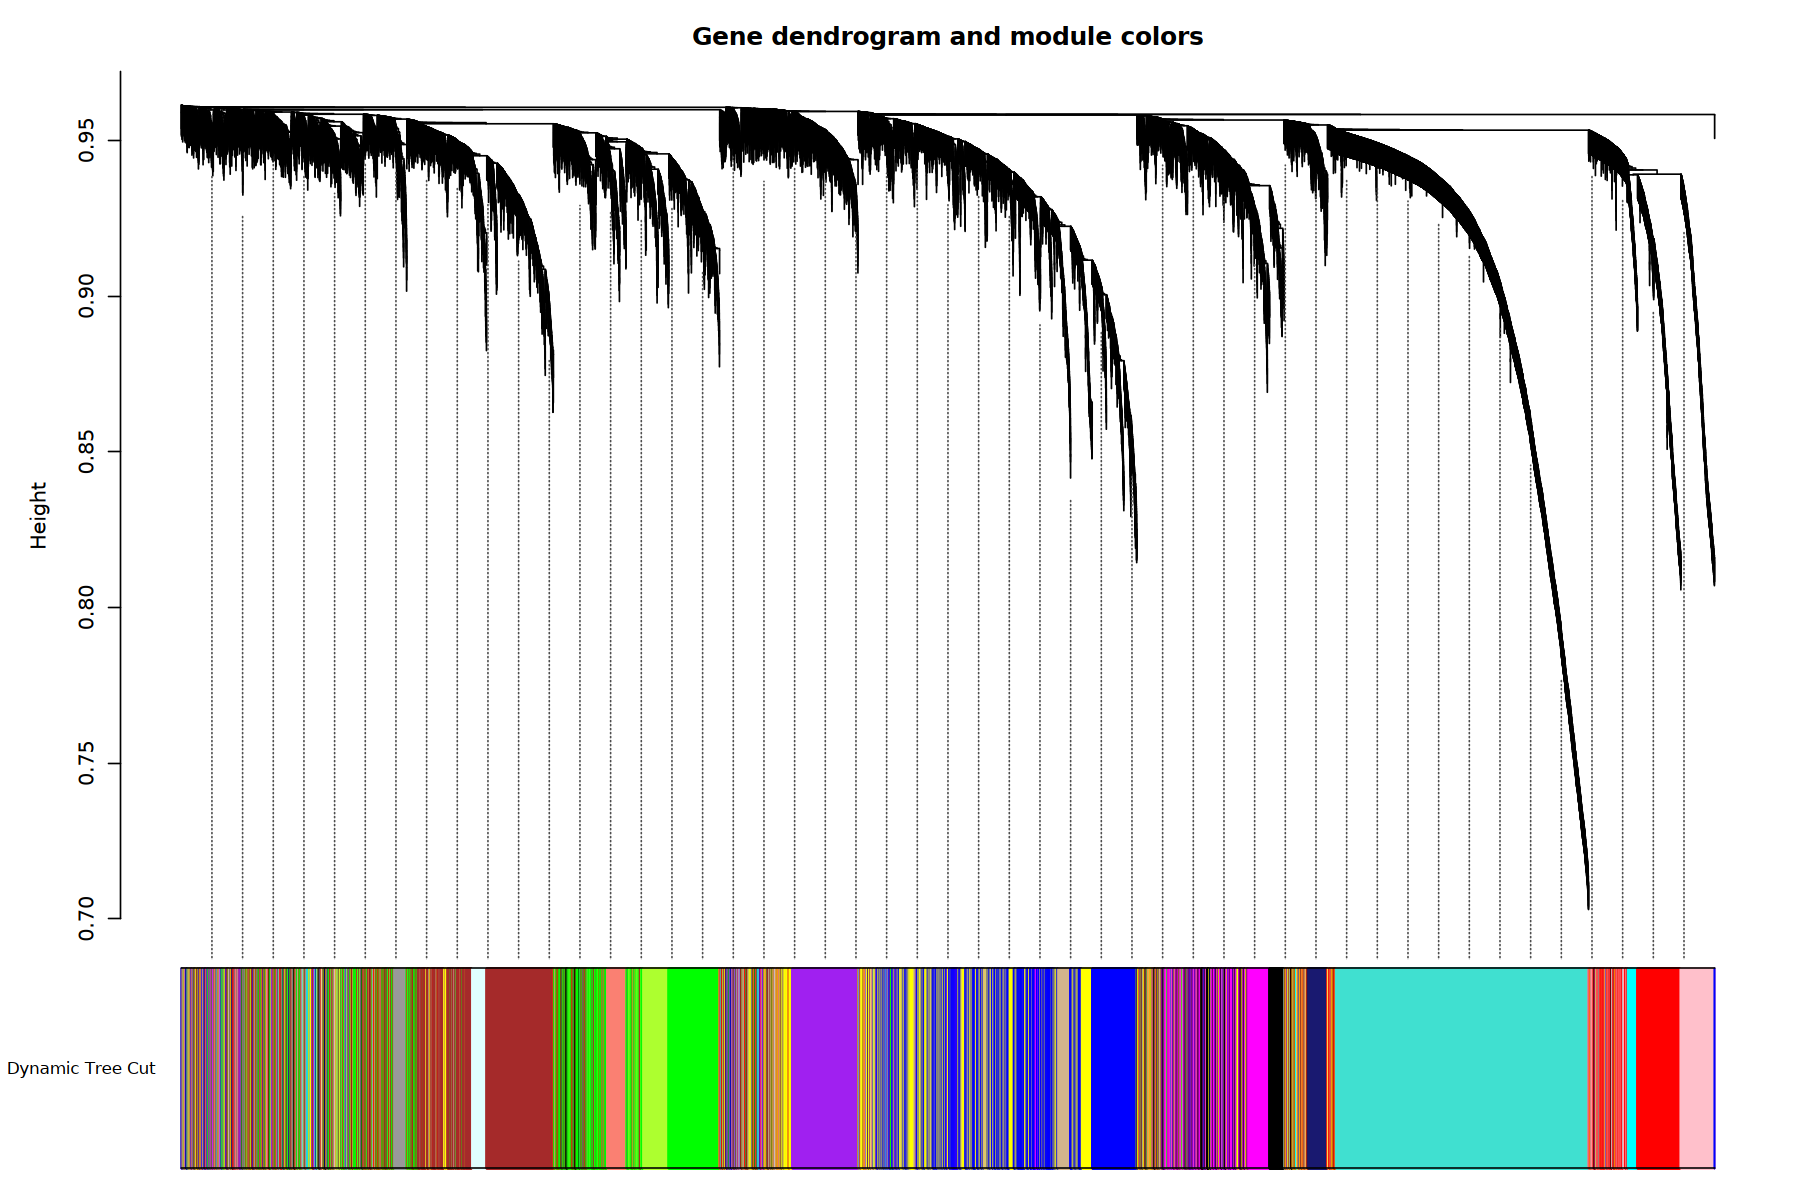

In [22]:
## SIGNED
# Convert numeric lables into colors
dynamicColors_sign <- labels2colors(dynamicMods_sign)
table(dynamicColors_sign)

# Plot the dendrogram and colors underneath
plotDendroAndColors(geneTree_sign, dynamicColors_sign, "Dynamic Tree Cut",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Gene dendrogram and module colors")


### F. merging modules whose GE profiles are similar

this is based on eigengenes, which is the first principal component of a given a gene expression matrix/module that acts as a representative summary profile for a gene module or cluster

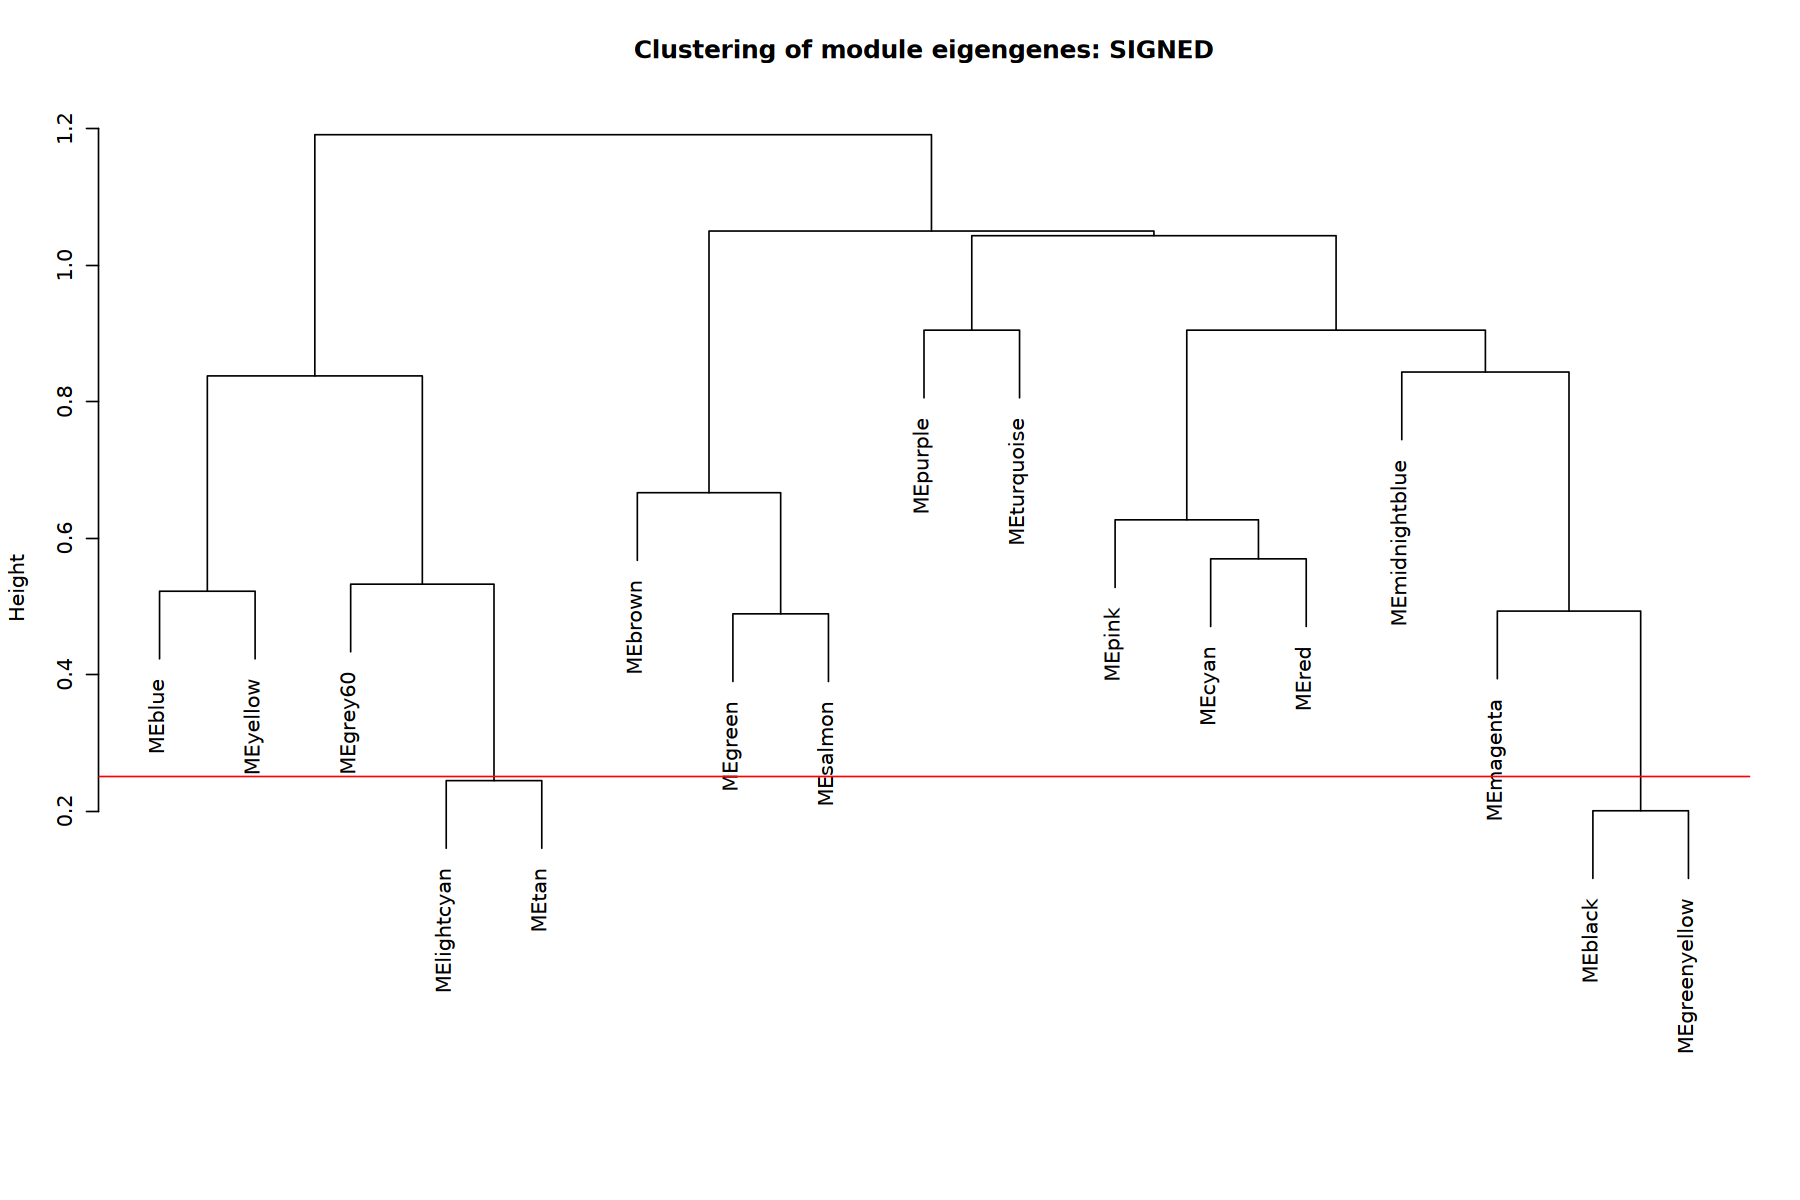

In [23]:
## SIGNED
# Calculate eigengenes
MEList_sign <- moduleEigengenes(dataExpr, colors = dynamicColors_sign)
MEs_sign <- MEList_sign$eigengenes

# Calculate dissimilarity of module eigengenes
MEDiss_sign <- 1-cor(MEs_sign)

# Cluster module eigengenes
METree_sign <- hclust(as.dist(MEDiss_sign), method = "average")

# Plot the result

# height cutoff of 0.25 - corresponds to a correlation of 0.75 to merge
MEDissThres <- 0.25

# Plot the cut line into the dendrogram
plot(METree_sign, main = "Clustering of module eigengenes: SIGNED", xlab = "", sub = "")
abline(h=MEDissThres, col = "red")

any branch with more than 75% correlation are related and will be merged - looks like none will be merged?

 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 17 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.


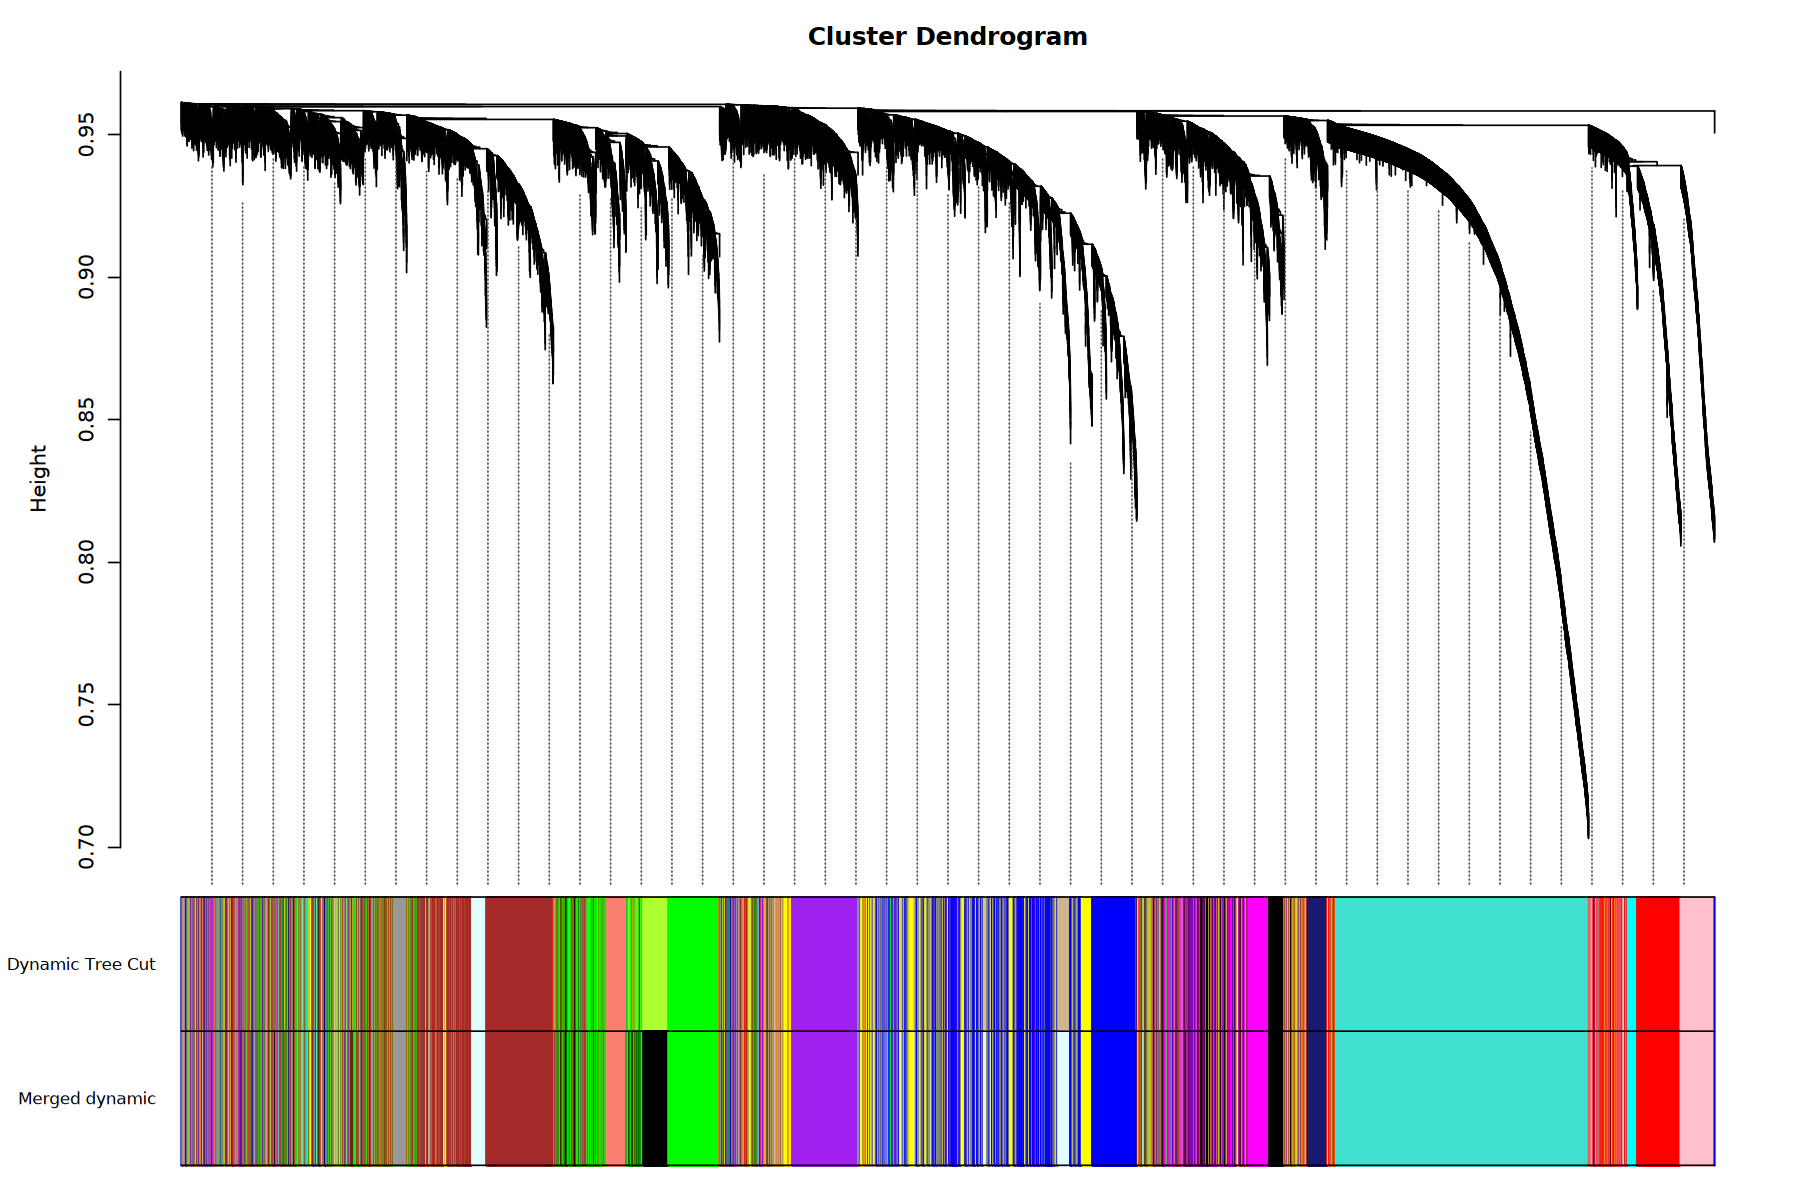

In [24]:
options(repr.plot.width = 15, repr.plot.height = 10)

## SIGNED
# Call an automatic merging function
merge_sign <- mergeCloseModules(dataExpr, dynamicColors_sign, cutHeight = MEDissThres, verbose = 3)

# The merged module colors
mergedColors_sign <- merge_sign$colors

# Eigengenes of the new merged modules:
mergedMEs_sign <- merge_sign$newMEs

# plot merged module colors
plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)


In [25]:
png("/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/mergedColors_dendrogram_p2.png", 
    width = 20, height = 12, units = "in", res = 300)

plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign),
                     c("Dynamic Tree Cut", "Merged dynamic"),
                     dendroLabels = FALSE, hang = 0.03,
                     addGuide = TRUE, guideHang = 0.05)
dev.off()

png 
  2

In [26]:
table(mergedColors_sign)

mergedColors_sign
       black         blue        brown         cyan        green       grey60 
        2068         3544         2626          401         2578          208 
   lightcyan      magenta midnightblue         pink       purple          red 
         792         1341          321         1387         1117         2287 
      salmon    turquoise       yellow 
         433         4379         2578 

16 co-expression modules with between 401 and 4379 genes

In [27]:
# write.csv(mergedColors_sign, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/mergedColors_sign.csv', row.names = FALSE)

## 3. quantifying module-trait associations
identify modules that are significantly associated with treatment exposures or measured traits (like growth)

### A. read in and format metadata

both treatment metadata and growth data

#### treatment data

In [28]:
# read in phase info
dataMeta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl('Nu', Sample))

# add missing rep number to sample name
dataMeta$Sample[dataMeta$Sample == "C_W5_W52"] <- "C2_W5_W52"

# fix wrong rep number to sample name
dataMeta$Sample[dataMeta$Sample == 'W2_B2_G04'] <- 'W2_B1_G04'

# keep only the samples seen in dataExpr
dataMeta <- dataMeta[dataMeta$Sample %in% rownames(dataExpr),]

# create combo trtmt column
dataMeta$combo_trtmt <- paste0(dataMeta$Phase1_treatment, '_', dataMeta$Phase2_treatment)


# check it out
dim(dataMeta)
head(dataMeta)


[1] 92 10

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control


values have to be numerical, so going to create a code for my treatments:

**phase 1 and 2 treatments**
1. control
2. warm
3. hypoxic
4. both

**temperature**
1. ambient
2. warm

**dissolved oxygen**
1. normoxic
2. hypoxic

In [29]:
# set factors
dataMeta$Phase1_treatment <- factor(dataMeta$Phase1_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase1_temp <- factor(dataMeta$Phase1_temp, c('ambient', 'warm'))
dataMeta$Phase1_DO <- factor(dataMeta$Phase1_DO, c('normoxic', 'hypoxic'))

dataMeta$Phase2_treatment <- factor(dataMeta$Phase2_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase2_temp <- factor(dataMeta$Phase2_temp, c('ambient', 'warm'))
dataMeta$Phase2_DO <- factor(dataMeta$Phase2_DO, c('normoxic', 'hypoxic'))

# convert categorical to numerical code for treatment info
### PHASE 1
dataMeta$P1_trtmt_code <- as.numeric(factor(dataMeta$Phase1_treatment))
dataMeta$P1_temp_code <- as.numeric(factor(dataMeta$Phase1_temp))
dataMeta$P1_DO_code <- as.numeric(factor(dataMeta$Phase1_DO))
### PHASE 2
dataMeta$P2_trtmt_code <- as.numeric(factor(dataMeta$Phase2_treatment))
dataMeta$P2_temp_code <- as.numeric(factor(dataMeta$Phase2_temp))
dataMeta$P2_DO_code <- as.numeric(factor(dataMeta$Phase2_DO))

# select only columns needed
metaData <- dataMeta[,-c(2:10)]

# set sample names as rownames
rownames(metaData) <- metaData$Sample
metaData <- metaData %>% select(-Sample)

dim(metaData)
head(metaData)


[1] 92  6

,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,4,2,2,4,2,2
B1_W5_O50,4,2,2,2,2,1
B2_B5_O51,4,2,2,4,2,2
B2_C4_O40,4,2,2,1,1,1
B3_B4_O41,4,2,2,4,2,2
B3_C3_O30,4,2,2,1,1,1


also creating binary variables for phase 1 and 2 treatments, so phase 1 both 0/1 (N/Y)

In [30]:
#### PHASE 1 ####
phase1.treatments <- dataMeta %>%
  select(Sample, Phase1_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_treatment,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
  rename_with(~ paste0("P1_", .x), -Sample)
head(phase1.treatments)

#### PHASE 2 ####
phase2.treatments <- dataMeta %>%
  select(Sample, Phase2_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase2_treatment,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
  rename_with(~ paste0("P2_", .x), -Sample)
head(phase2.treatments)

#### MERGE ####
trtmt_bin <- merge(phase1.treatments, phase2.treatments, by = 'Sample') %>%
column_to_rownames(var = 'Sample')
head(trtmt_bin)

Sample,P1_both,P1_control,P1_hypoxic,P1_warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,1,0,0,0
B1_W5_O50,1,0,0,0
B2_B5_O51,1,0,0,0
B2_C4_O40,1,0,0,0
B3_B4_O41,1,0,0,0
B3_C3_O30,1,0,0,0


Sample,P2_both,P2_warm,P2_control,P2_hypoxic
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,1,0,0,0
B1_W5_O50,0,1,0,0
B2_B5_O51,1,0,0,0
B2_C4_O40,0,0,1,0
B3_B4_O41,1,0,0,0
B3_C3_O30,0,0,1,0


,P1_both,P1_control,P1_hypoxic,P1_warm,P2_both,P2_warm,P2_control,P2_hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,1,0,0,0,1,0,0,0
B1_W5_O50,1,0,0,0,0,1,0,0
B2_B5_O51,1,0,0,0,1,0,0,0
B2_C4_O40,1,0,0,0,0,0,1,0
B3_B4_O41,1,0,0,0,1,0,0,0
B3_C3_O30,1,0,0,0,0,0,1,0


add this to the meta data df

In [31]:
metaData2 <- merge(metaData, trtmt_bin, by = 0) %>%
column_to_rownames(var = 'Row.names')
head(metaData2)

,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code,P1_both,P1_control,P1_hypoxic,P1_warm,P2_both,P2_warm,P2_control,P2_hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B1_W5_O50,4,2,2,2,2,1,1,0,0,0,0,1,0,0
B2_B5_O51,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B2_C4_O40,4,2,2,1,1,1,1,0,0,0,0,0,1,0
B3_B4_O41,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B3_C3_O30,4,2,2,1,1,1,1,0,0,0,0,0,1,0


In [32]:
metaData <- metaData2

#### growth data

In [33]:
p2_growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase2.1_weights.csv')

# add leading zeros to single digit tag num
p2_growth$Tag_num <- sprintf("%02d", p2_growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(p2_growth$Phase_1_treat, 1, 1)
p2_str <- str_sub(p2_growth$Phase_2_treat, 1, 1)
p2_growth$Sample <- paste0(p1_str, p2_growth$Phase_1_rep, '_', p2_str, p2_growth$Phase_2_rep, '_', p2_growth$Tag_color, p2_growth$Tag_num)
head(p2_growth$Sample)

# pull out growth data for matching samples
p2_growth.df <- p2_growth[p2_growth$Sample %in% rownames(metaData), ]

# check it out
dim(p2_growth.df) # 91 samples
dim(metaData) # 93 samples

[1] "B1_B1_O01" "B1_B1_O02" "B1_B2_O13" "B1_B2_O14" "B1_B3_O25" "B1_B3_O26"

[1] 92 33

[1] 92 14

In [34]:
metaData[!rownames(metaData) %in% p2_growth.df$Sample,]

P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code,P1_both,P1_control,P1_hypoxic,P1_warm,P2_both,P2_warm,P2_control,P2_hypoxic
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [35]:
head(dataMeta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,4,2,2,4,2,2
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,4,2,2,2,2,1
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,4,2,2,4,2,2
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,4,2,2,1,1,1
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,4,2,2,4,2,2
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,4,2,2,1,1,1


i think C_W5_W52 should be **C2_W5_W52** actually and W2_B2_G04 should be **W2_B1_G04**

changing the names in both metaData and dataExpr 

In [36]:
rownames(dataMeta) <- dataMeta$Sample

# add missing rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(metaData)[rownames(metaData) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(dataMeta)[rownames(dataMeta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(metaData)[rownames(metaData) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(dataMeta)[rownames(dataMeta) == 'W2_B2_G04'] <- 'W2_B1_G04'

pulling out the growth data now - should be the same number of samples ...

In [37]:
# pull out growth data for matching samples
p2_growth.df2 <- p2_growth[p2_growth$Sample %in% rownames(metaData), ]

# check it out
dim(p2_growth.df2) # 93 samples
dim(metaData) # 93 samples

[1] 92 33

[1] 92 14

so all good now with matching sample names!

now pulling out only the growth columns and merging with the other meta data df 

In [38]:
# select growth columns
p2_growth.df2 <- p2_growth.df2 %>%
select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

# sample is the rowname
rownames(p2_growth.df2) <- p2_growth.df2$Sample
p2_growth.df2 <- p2_growth.df2 %>% select(-Sample)


head(p2_growth.df2)

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<dbl>,<dbl>,<chr>
B1_B1_O01,210.2755,120.72448,0.574125224
B1_W5_O50,315.8883,85.61170,0.271018901
B2_B5_O51,114.3215,44.47852,0.389065292
B2_C4_O40,164.9903,55.10972,0.33401798
B3_B4_O41,197.9250,116.17500,0.586964759
B3_C3_O30,316.0466,241.35336,0.763663743


#### merge growth and treatment data

In [39]:
# merge dfs
metaData_merge <- merge(p2_growth.df2, metaData, by = 'row.names')

# set samples as rownames
metaData_merge <- metaData_merge %>% 
column_to_rownames(var = 'Row.names')

dim(metaData_merge)
head(metaData_merge)

[1] 92 17

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code,P1_both,P1_control,P1_hypoxic,P1_warm,P2_both,P2_warm,P2_control,P2_hypoxic
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,210.2755,120.72448,0.574125224,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B1_W5_O50,315.8883,85.61170,0.271018901,4,2,2,2,2,1,1,0,0,0,0,1,0,0
B2_B5_O51,114.3215,44.47852,0.389065292,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B2_C4_O40,164.9903,55.10972,0.33401798,4,2,2,1,1,1,1,0,0,0,0,0,1,0
B3_B4_O41,197.9250,116.17500,0.586964759,4,2,2,4,2,2,1,0,0,0,1,0,0,0
B3_C3_O30,316.0466,241.35336,0.763663743,4,2,2,1,1,1,1,0,0,0,0,0,1,0


In [40]:
# define # of genes and samples
nSamples <- nrow(dataExpr) # 92 samples
nGenes <- ncol(dataExpr) # 23,217 genes

eigengene ~ summary profile of the module

now can correlate eigengenes with external traits and look for most significant associations

growth meaning the growth from the beginning of phase 2 to the end of phase 2 - we do not have data on these oysters' growth before and after phase 1. The ratio of tissue to shell growth is a proxy for fitness (more tissue = investing in reproduction, more shell = investing in defense)

### B. plot module-trait relationships

In [41]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together

moduleTraitCor <- cor(MEs, metaData_merge, use = "p") # correlate with traits - using Pearson correlations

moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples) # compute p-values - uses student's t-distribution

In [42]:
# convert correlation matrix to df
cor.df <- as.data.frame(moduleTraitCor) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'Cor')

head(cor.df)

module,Trait,Cor
<chr>,<chr>,<dbl>
MEgrey60,Actual_shell_growth_mg,-0.18706800
MEgrey60,Actual_tissue_growth_mg,-0.16814651
MEgrey60,Ratio_tissue_shell_mg,0.13226806
MEgrey60,P1_trtmt_code,0.03114977
MEgrey60,P1_temp_code,0.04393369
MEgrey60,P1_DO_code,0.01255181


In [43]:
# convert pvalue matrix to df
pval.df <- as.data.frame(moduleTraitPvalue) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'pvalue')

head(pval.df)

module,Trait,pvalue
<chr>,<chr>,<dbl>
MEgrey60,Actual_shell_growth_mg,0.07417077
MEgrey60,Actual_tissue_growth_mg,0.10911509
MEgrey60,Ratio_tissue_shell_mg,0.20880619
MEgrey60,P1_trtmt_code,0.76817376
MEgrey60,P1_temp_code,0.67752970
MEgrey60,P1_DO_code,0.90547238


In [44]:
# merge the two dfs
module.df <- cor.df %>%
left_join(pval.df, by = c('module', 'Trait')) %>%
# add vol to denote significance for bold labeling
mutate(
    label = sprintf("%.2f\n(%.1g)", Cor, pvalue),
    sig = !is.na(pvalue) & pvalue < 0.05
  )

module.df <- module.df %>%
  mutate(
    Trait = factor(Trait, levels = sort(unique(Trait))),
    module = factor(module, levels = sort(unique(module)))
  )

head(module.df)

module,Trait,Cor,pvalue,label,sig
<fct>,<fct>,<dbl>,<dbl>,<chr>,<lgl>
MEgrey60,Actual_shell_growth_mg,-0.18706800,0.07417077,-0.19 (0.07),FALSE
MEgrey60,Actual_tissue_growth_mg,-0.16814651,0.10911509,-0.17 (0.1),FALSE
MEgrey60,Ratio_tissue_shell_mg,0.13226806,0.20880619,0.13 (0.2),FALSE
MEgrey60,P1_trtmt_code,0.03114977,0.76817376,0.03 (0.8),FALSE
MEgrey60,P1_temp_code,0.04393369,0.67752970,0.04 (0.7),FALSE
MEgrey60,P1_DO_code,0.01255181,0.90547238,0.01 (0.9),FALSE


In [45]:
unique(module.df$Trait)

[1] Actual_shell_growth_mg  Actual_tissue_growth_mg Ratio_tissue_shell_mg  
 [4] P1_trtmt_code           P1_temp_code            P1_DO_code             
 [7] P2_trtmt_code           P2_temp_code            P2_DO_code             
[10] P1_both                 P1_control              P1_hypoxic             
[13] P1_warm                 P2_both                 P2_warm                
[16] P2_control              P2_hypoxic             
17 Levels: Actual_shell_growth_mg Actual_tissue_growth_mg ... Ratio_tissue_shell_mg

In [50]:
df.clean <- module.df %>%
  mutate(Trait = case_match(Trait,
                           "Actual_shell_growth_mg" ~ "Shell Growth",
                           "Actual_tissue_growth_mg" ~ "Tissue Growth",
                            "Ratio_tissue_shell_mg" ~ "Tissue:Shell Growth",
                            "P1_trtmt_code" ~ "Phase 1 Interaction",
                            "P2_trtmt_code" ~ "Phase 2 Interaction",
                            "P1_temp_code" ~ "Phase 1 Temp",
                            "P2_temp_code" ~ "Phase 2 Temp",
                            "P1_DO_code" ~ "Phase 1 DO",
                            "P2_DO_code" ~ "Phase 2 DO",
                           .default = Trait)) %>% # Keeps unchanged values as they are
# add col that denotes if the trait is for treatment or growth data
mutate(trait_type = ifelse(
    grepl('Growth', Trait),
    'Phase 2 Growth',
    ifelse(grepl('_', Trait),
           'Binary Treatments',
    'Treatments'
    )
       )
       )

head(df.clean)

module,Trait,Cor,pvalue,label,sig,trait_type
<fct>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
MEgrey60,Shell Growth,-0.18706800,0.07417077,-0.19 (0.07),FALSE,Phase 2 Growth
MEgrey60,Tissue Growth,-0.16814651,0.10911509,-0.17 (0.1),FALSE,Phase 2 Growth
MEgrey60,Tissue:Shell Growth,0.13226806,0.20880619,0.13 (0.2),FALSE,Phase 2 Growth
MEgrey60,Phase 1 Interaction,0.03114977,0.76817376,0.03 (0.8),FALSE,Treatments
MEgrey60,Phase 1 Temp,0.04393369,0.67752970,0.04 (0.7),FALSE,Treatments
MEgrey60,Phase 1 DO,0.01255181,0.90547238,0.01 (0.9),FALSE,Treatments


In [49]:
unique(df.clean$Trait)
unique(df.clean$trait_type)

[1] "Shell Growth"        "Tissue Growth"       "Tissue:Shell Growth"
 [4] "Phase 1 Interaction" "Phase 1 Temp"        "Phase 1 DO"         
 [7] "Phase 2 Interaction" "Phase 2 Temp"        "Phase 2 DO"         
[10] "P1_both"             "P1_control"          "P1_hypoxic"         
[13] "P1_warm"             "P2_both"             "P2_warm"            
[16] "P2_control"          "P2_hypoxic"

[1] "Phase 2 Growth"   "Treatments"       "Binary Treatment"

In [51]:
# making a copy of the above df
df.clean2 <- df.clean

saving df above as csv so I don't have to run all of the code to edit the heatmap

In [49]:
# write.csv(df.clean, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/heatmap_data.csv', row.names = FALSE)

the phase interaction term is not biologically accurate or relevant, so going to remove and just plot treatments/binary treatments

In [57]:
df.clean3 <- df.clean2 %>% filter(!grepl('Interaction', Trait))
head(df.clean3)

module,Trait,Cor,pvalue,label,sig,trait_type
<fct>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
MEgrey60,Shell Growth,-0.18706800,0.074170774,-0.19 (0.07),FALSE,Phase 2 Growth
MEgrey60,Tissue Growth,-0.16814651,0.109115090,-0.17 (0.1),FALSE,Phase 2 Growth
MEgrey60,Tissue:Shell Growth,0.13226806,0.208806191,0.13 (0.2),FALSE,Phase 2 Growth
MEgrey60,Phase 1 Temp,0.04393369,0.677529697,0.04 (0.7),FALSE,Treatments
MEgrey60,Phase 1 DO,0.01255181,0.905472378,0.01 (0.9),FALSE,Treatments
MEgrey60,Phase 2 Temp,-0.28615327,0.005688208,-0.29 (0.006),TRUE,Treatments


In [63]:
unique(df.clean3$Trait)
unique(df.clean3$trait_type)

[1] Shell Growth        Tissue Growth       Tissue:Shell Growth
 [4] Phase 1 Temp        Phase 1 DO          Phase 2 Temp       
 [7] Phase 2 DO          P1_both             P1_control         
[10] P1_hypoxic          P1_warm             P2_both            
[13] P2_warm             P2_control          P2_hypoxic         
15 Levels: Shell Growth Tissue Growth Tissue:Shell Growth ... P2_both

[1] "Phase 2 Growth"    "Treatments"        "Binary Treatments"

In [68]:
# remove module for all other genes 
df.clean3 <- df.clean3 %>% filter(module != 'MEgrey60')

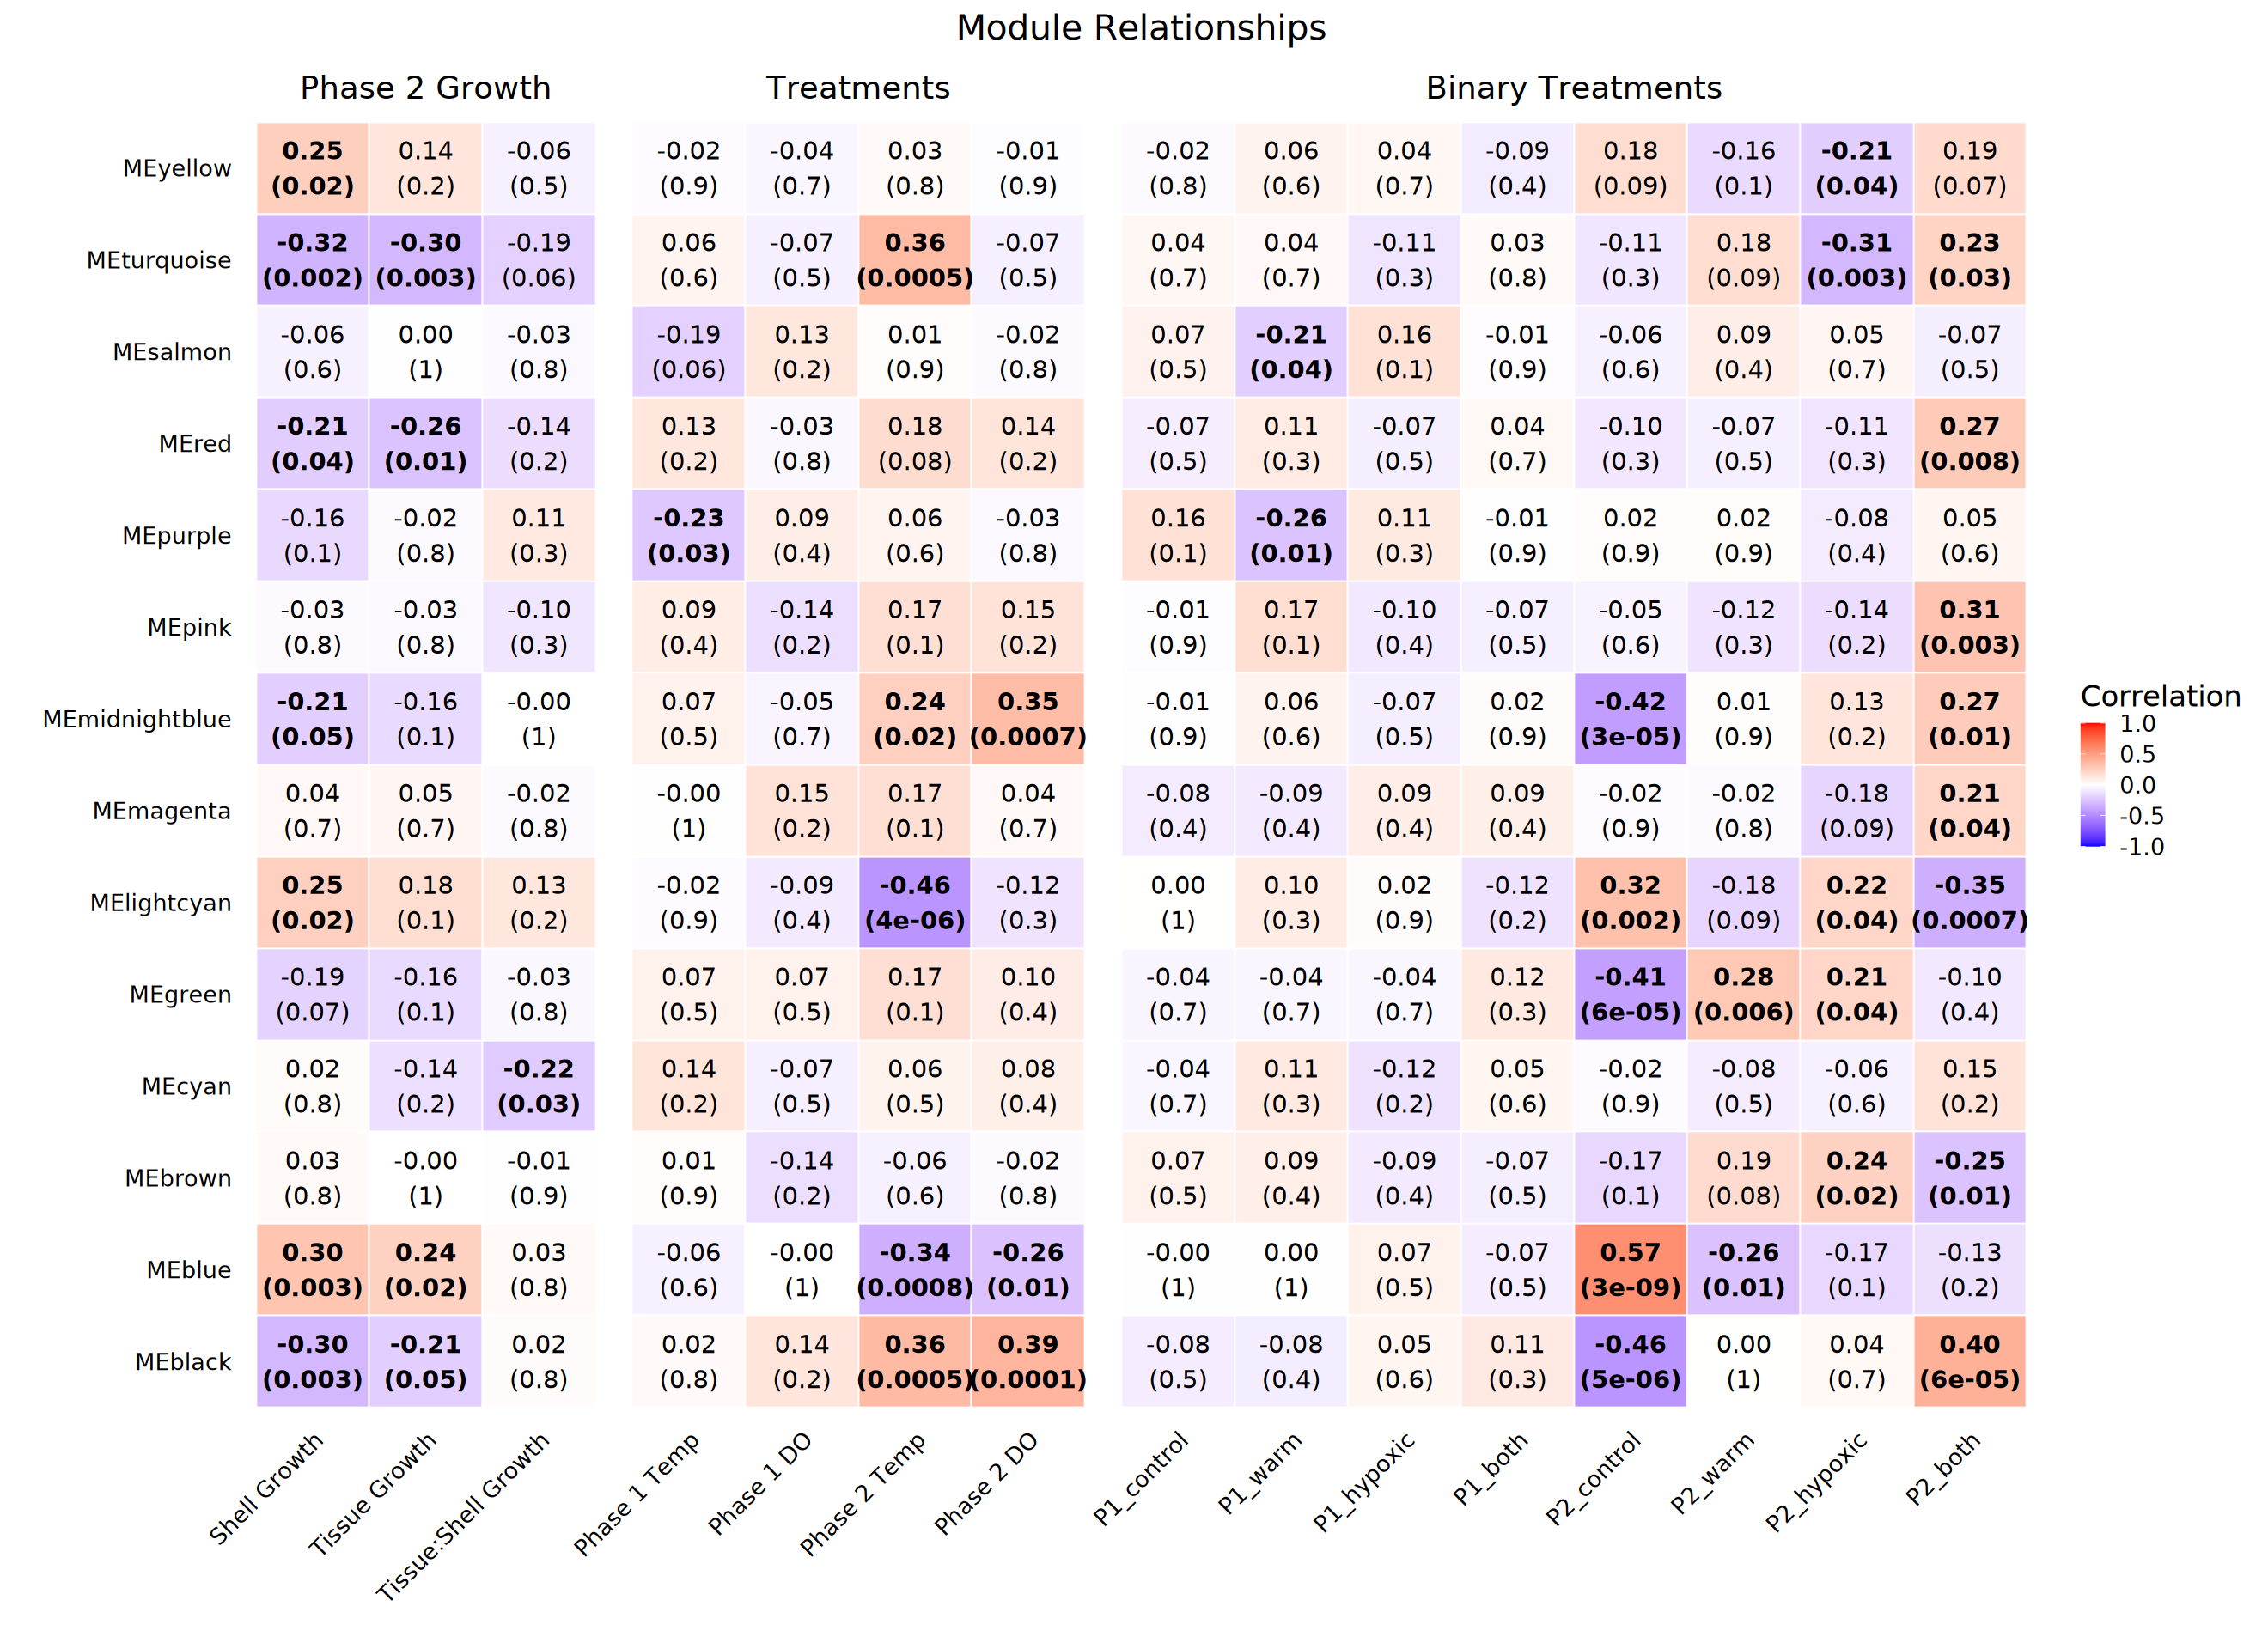

In [70]:
options(repr.plot.width = 22, repr.plot.height = 16)

# reorder x-axis
trait_order <- c("Shell Growth", "Tissue Growth", "Tissue:Shell Growth", 
                 "Phase 1 Temp", "Phase 1 DO", "Phase 2 Temp", "Phase 2 DO",
                'P1_control', 'P1_warm', 'P1_hypoxic', 'P1_both',
                'P2_control', 'P2_warm', 'P2_hypoxic', 'P2_both')
df.clean3$Trait <- factor(df.clean3$Trait, levels = trait_order)
# remove binary treatment bins - going to plot seperately
df.clean3 <- na.omit(df.clean3)

# reorder facet grid
df.clean3$trait_type <- factor(
  df.clean3$trait_type,
  levels = c("Phase 2 Growth", "Treatments", "Binary Treatments")
)

heatmap1 <- ggplot(df.clean3, aes(x = Trait, y = module, fill = Cor)) +
  geom_tile(color = "white") +
  
  # text annotations
  geom_text(
    aes(
      label = label,
      fontface = ifelse(sig, "bold", "plain")
    ),
    size = 6
  ) +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    limits = c(-1, 1)
  ) +

  facet_grid(
    ~ trait_type,
    scales = "free_x",
    space = "free_x"
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = 'black'),
      axis.text.y = element_text(color = 'black'),
    panel.grid = element_blank(),
      plot.title = element_text(hjust = .5),
      strip.text = element_text(color = 'black', size = 22)
  ) +
  
  labs(
    title = "Module Relationships",
    x = "",
    y = "",
    fill = "Correlation"
  )

heatmap1

In [71]:
ggsave(
  filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/module_trait_heatmap.png",
  plot = heatmap1,
  width = 22,
  height = 16,
  dpi = 300
)

#### binary treatments
now adding in the binary variables for phase 1 and 2 treatments

In [78]:
df.clean2 <- df.clean2 %>%
mutate(phase = ifelse(
    grepl('P1', Trait),
    'Phase 1 Treatment',
    'Phase 2 Treatment'
    )
       )

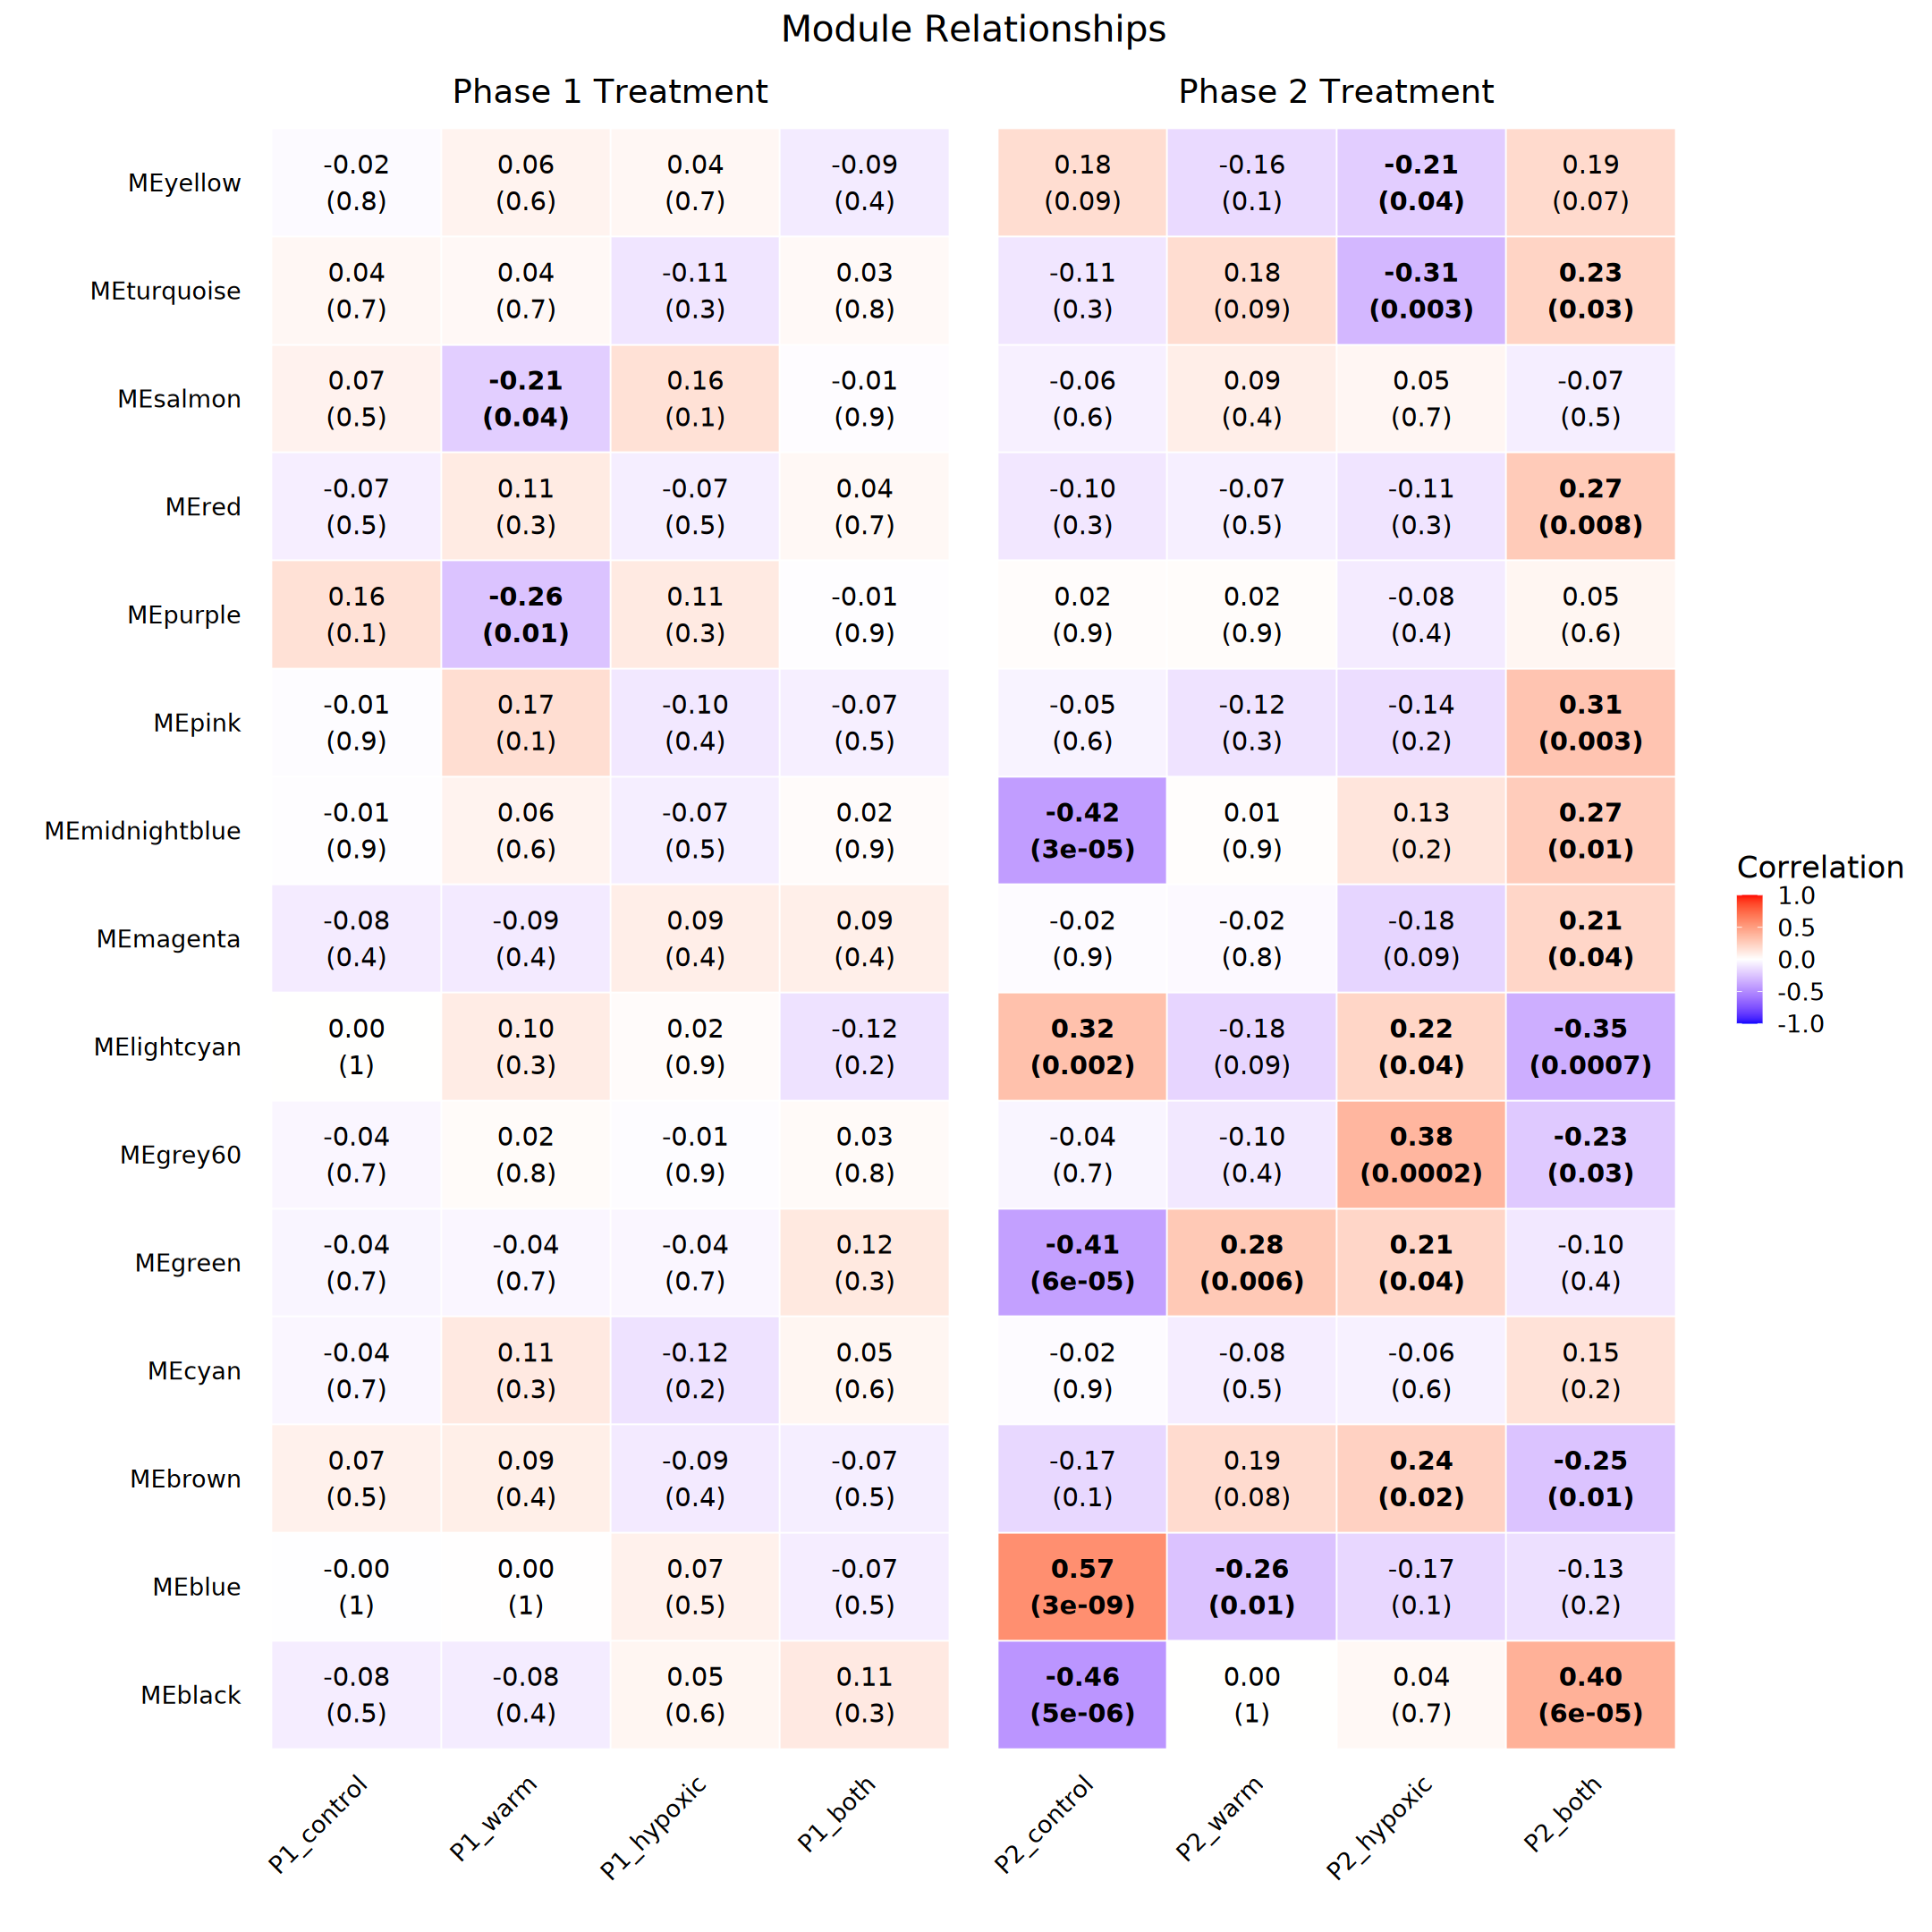

In [53]:
# reorder x-axis
trait_order <- c("P1_control", "P1_warm", "P1_hypoxic", "P1_both", "P2_control", "P2_warm", "P2_hypoxic", "P2_both")
df.clean2$Trait <- factor(df.clean2$Trait, levels = trait_order)
# remove binary treatment bins - going to plot seperately
df.clean2 <- na.omit(df.clean2)

heatmap_bin <- ggplot(df.clean2, aes(x = Trait, y = module, fill = Cor)) +
  geom_tile(color = "white") +
  
  # text annotations
  geom_text(
    aes(
      label = label,
      fontface = ifelse(sig, "bold", "plain")
    ),
    size = 6
  ) +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    limits = c(-1, 1)
  ) +

  facet_grid(
    ~ phase,
    scales = "free_x",
    space = "free_x"
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = 'black'),
      axis.text.y = element_text(color = 'black'),
    panel.grid = element_blank(),
      plot.title = element_text(hjust = .5),
      strip.text = element_text(color = 'black', size = 22)
  ) +
  
  labs(
    title = "Module Relationships",
    x = "",
    y = "",
    fill = "Correlation"
  )

heatmap_bin

In [54]:
ggsave(
  filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/binary_module_trait_heatmap.png",
  plot = heatmap_bin,
  width = 18,
  height = 18,
  dpi = 300
)

okay so yea, still don't see any modules that are significantly correlated with phase 1 treatments, even when we break it down. 

We do see some modules that are significantly correlated with specific treatments 
- yellow -> higher expression in p2 both compared to all other treatments
- turquoise -> higher expression in p2 warmer, lower expression in p2 hypoxic compared to all other treatments
- tan -> lower expression in p2 control, higher expression in p2 warm
- salmon -> lower expression in p2 control, higher expression in p2 both
- red -> higher expression in p2 warm and hypoxic, lower expression in p2 both (difference between single and multiple stressors?)
- purple -> higher expression in p2 control and hypoxic, lower expression in p2 warm and both (driven by temp treatment)
- pink -> highr expression in p2 both
- magenta -> lower expression in p2 control, higher in p2 both
- lightcyan -> higher expression in p2 both
- green -> lower expression in p2 control, higher expression in p2 warm
- cyan -> higher expression in p2 both
- brown -> higher expression in p2 control, lower expression in p2 warm
- blue -> higher expression in p2 control
- black -> higher expression in p2 both

so now we can see more clearly what's "under the hood" of the heatmap before (when we see phase 2 interaction, phase 2 temp and DO all correlated (like in salmon and magenta), it's bc we see a correlation with control treatment and both treatment)

it would be interesting to look more into the turquoise and purple modules, as the warm and hypoxic treatments have opposing correlations with these modules

In [55]:
# write csv to save the module eigengenes
 # write.csv(MEs, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_ModuleEigengenes.csv')

## MEs boxplots by treatment group

inspo for this comes from [Gurr's code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/Day21_WGCNA_all.R) - plotting every module's ME (module eigengene) for each treatment combination - this will allow me to take a closer look at the relationship between modules and phase 1 and 2 treatments

first - need to make sure the sample name mixup from above carries down here

In [61]:
# add missing rep number to sample name
rownames(metaData_merge)[rownames(metaData_merge) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(dataMeta)[rownames(dataMeta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(metaData_merge)[rownames(metaData_merge) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(dataMeta)[rownames(dataMeta) == 'W2_B2_G04'] <- 'W2_B1_G04'

# update sample column info
metaData_merge$Sample <- rownames(metaData_merge)
dataMeta$Sample <- rownames(dataMeta)

then create df to plot boxplots - want the metadata and module eigengene info in long format

In [62]:
# Create ME table
MEs_df <- as.data.frame(MEs)
MEs_df$Sample <- rownames(MEs_df)

# format metadata and merge with MEs
dataMeta2 <- dataMeta[,1:10]
meta_merge <- merge(dataMeta2, metaData_merge, by = 'Sample')
dim(meta_merge)

# merge MEs and metadata
MEsPlotting <- merge(MEs_df, meta_merge, by = 'Sample')

# Melt to long format
MEsPlotting_melt <- reshape2::melt(
  MEsPlotting,
  id.vars = c("Sample",
              "Phase1_treatment",
              "Phase1_temp",
              "Phase1_DO",
              "Phase1_TankRep",
              "Phase2_treatment",
              "Phase2_temp",
              "Phase2_DO",
              "Phase2_TankRep",
              "combo_trtmt",
              'Actual_shell_growth_mg',
              'Actual_tissue_growth_mg', 
              'Ratio_tissue_shell_mg'
             ),
  variable.name = "Module",
  value.name = "Eigengene"
)

MEsPlotting_melt <- MEsPlotting_melt %>%
filter(!grepl('code', Module)) # remove treatment code rows

head(MEsPlotting_melt)

[1] 92 27

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Module,Eigengene
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.574125224,MEgrey60,0.07434743
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.271018901,MEgrey60,0.07549295
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.389065292,MEgrey60,0.12038734
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.33401798,MEgrey60,0.04819095
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.586964759,MEgrey60,0.01951065
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.763663743,MEgrey60,-0.01524540


In [63]:
# save metadata in case I skip code above
# write.csv(MEsPlotting_melt, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_metadata.csv')

make boxplot!

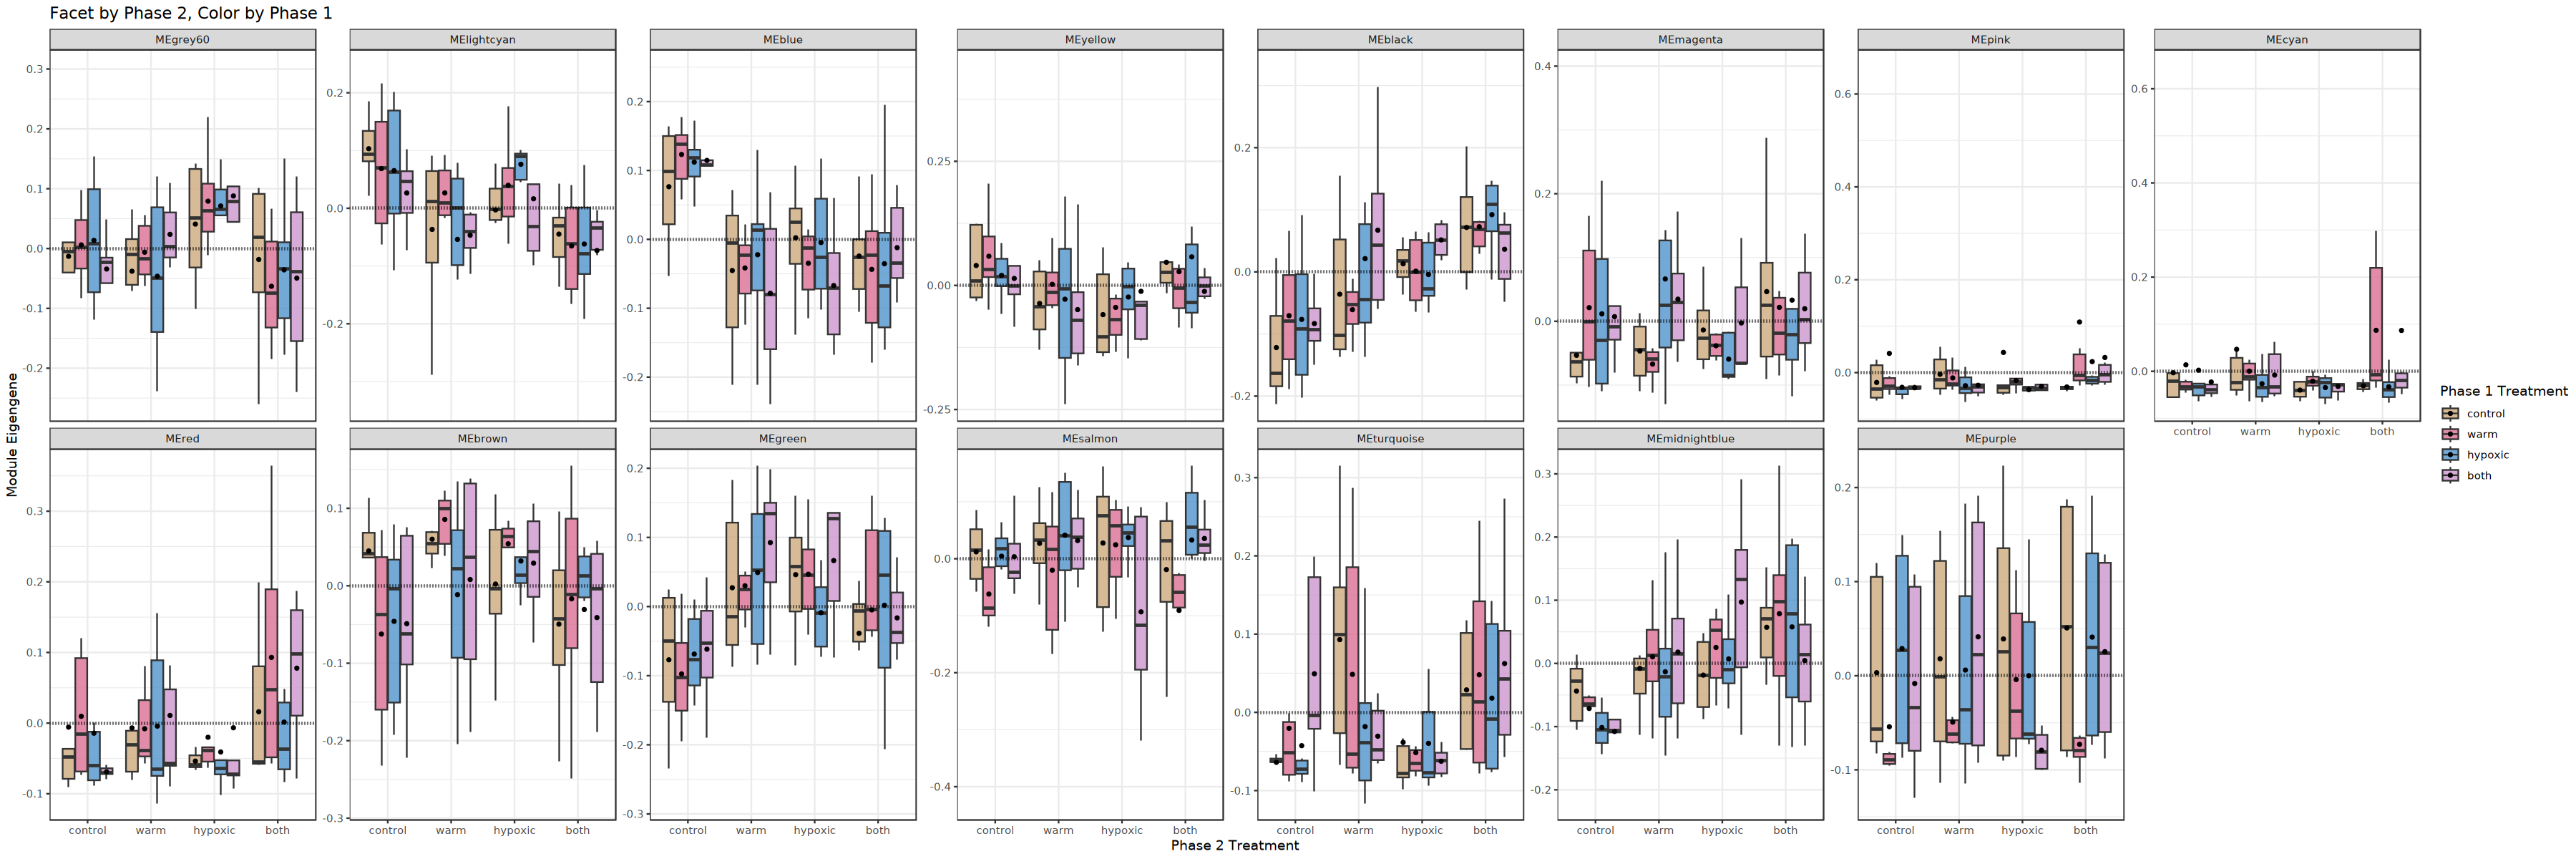

In [74]:
options(repr.plot.width = 30, repr.plot.height = 10)

MEs_boxplot <- ggplot(MEsPlotting_melt  %>% filter(!str_detect(Module, "P1|P2")), # remove non-module values
       aes(x = Phase2_treatment,
           y = Eigengene,
           fill = factor(Phase1_treatment))) +
# boxplot
  geom_boxplot(position = position_dodge(0.8),
               outlier.shape = NA,
               alpha = 0.8) +
# colors
scale_fill_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # point for mean
  stat_summary(fun = mean,
               geom = "point",
               color = "black",
               position = position_dodge(0.8),
               size = 1) +
  # horizontal line for 0
  geom_hline(yintercept = 0,
             linetype = "dotted",
             linewidth = 1) +
  # labels
  ylab("Module Eigengene") +
labs(fill = 'Phase 1 Treatment', 
     x = 'Phase 2 Treatment',
    title = 'Facet by Phase 2, Color by Phase 1') +
# theme
  theme_bw() +
# create grid
  facet_wrap(~ Module, scales = "free_y", nrow = 2)

MEs_boxplot

x-axis: module eigengene - representative gene expression profile for that module

dotted line denotes no expression, pos = higher expr and neg = lower expr

**MEbrown** is interesting - expression of those genes are higher if oysters returned to control conditions - might be indicative of general stress response? since the gene cluster responds somewhat similarly in all the other treatments

**MEturquoise** is also interesting - we start to see some treatment specific expression based on phase 1 - higher expression in BC compared to all other oysters in control conditions later in life, regardless of phase 1 treatment - also see higher expression in CW and WW compared to HW and BW

In [75]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/MEs_boxplots_p2.png', 
  plot = MEs_boxplot, 
  width = 30,       # Half the width
  height = 10,     # Roughly half the height
  units = "in", 
  dpi = 300         # High resolution for clarity
)

just wondering what this looks like when we switch the faceting and coloring ...

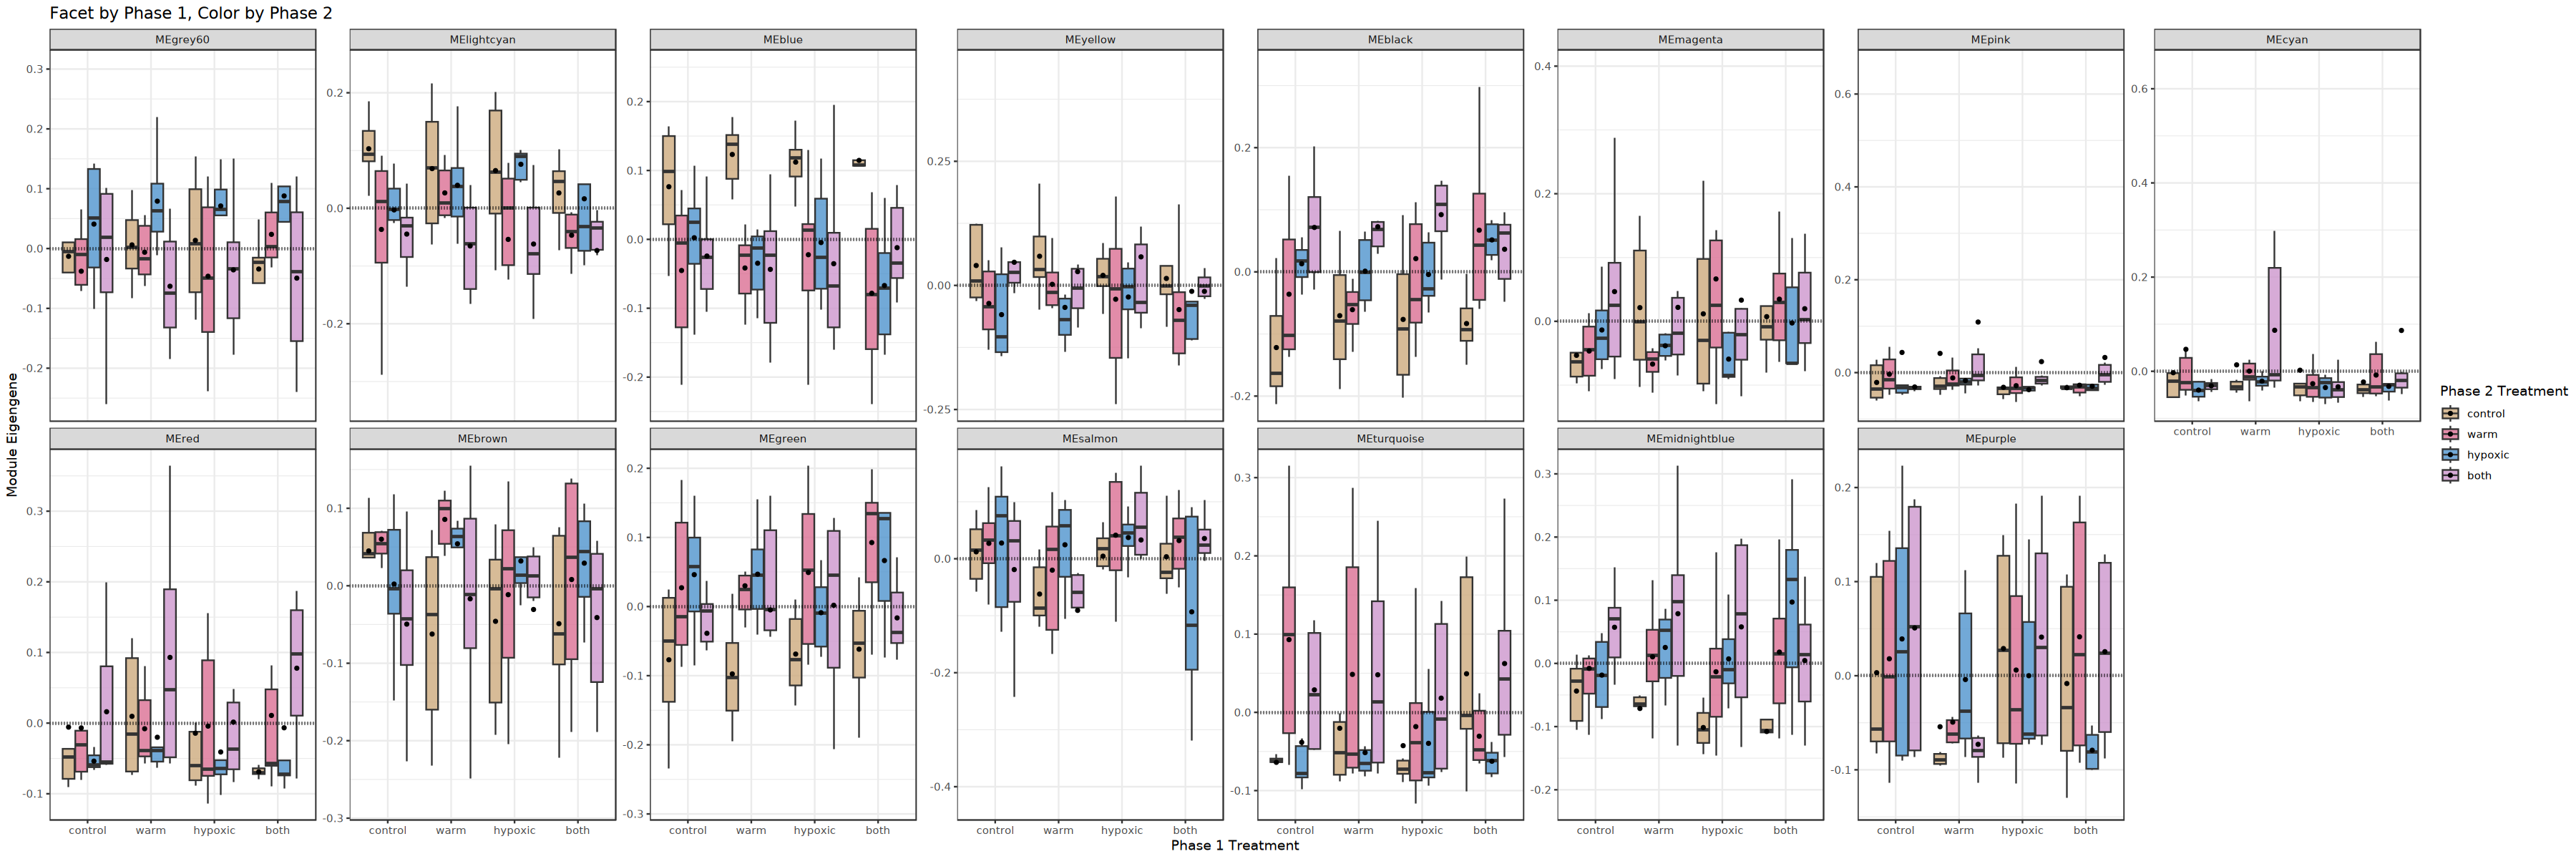

In [77]:
options(repr.plot.width = 30, repr.plot.hieght = 10)

MEs_boxplot <- ggplot(MEsPlotting_melt  %>% filter(!str_detect(Module, "P1|P2")), # remove non-module values
       aes(x = Phase1_treatment,
           y = Eigengene,
           fill = factor(Phase2_treatment))) +
# boxplot
  geom_boxplot(position = position_dodge(0.8),
               outlier.shape = NA,
               alpha = 0.8) +
# colors
scale_fill_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # point for mean
  stat_summary(fun = mean,
               geom = "point",
               color = "black",
               position = position_dodge(0.8),
               size = 1) +
  # horizontal line for 0
  geom_hline(yintercept = 0,
             linetype = "dotted",
             linewidth = 1) +
  # labels
  ylab("Module Eigengene") +
labs(fill = 'Phase 2 Treatment', 
     x = 'Phase 1 Treatment',
    title = 'Facet by Phase 1, Color by Phase 2') +
# theme
  theme_bw() +
# create grid
  facet_wrap(~ Module, scales = "free_y", nrow = 2)

MEs_boxplot

**MEmagenta** looks interesting - you see this stepwise increase in expression of those genes depending on the phase 2 treatment (kinda regardless of what phase 1 was)

## Identify hub genes
hub genes = gene with the most connectivity within its module 

In [56]:
hubGenes <- chooseTopHubInEachModule(dataExpr, # vst expr. matrix
                         mergedColors_sign, # from dendogram above
                         omitColors = "grey", # grey module = genes not assigned to any module
                         power = 5, 
                         type = "signed")

# make into df, assign modules in column
hubGenes.df <- as.data.frame(hubGenes) %>%
mutate(module = rownames(.))
# remove row names
rownames(hubGenes.df) <- NULL

hubGenes.df

hubGenes,module
<chr>,<chr>
LOC111119101,black
LOC111106458,blue
LOC111133485,brown
LOC111126756,cyan
LOC111135975,green
LOC111120563,grey60
LOC111118145,lightcyan
LOC111129175,magenta
LOC111099585,midnightblue


from the heatmap and boxplots above, the modules I'm most interested is:
- **blue**: [LOC111106458](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111106458) 26S proteasome non-ATPase regulatory subunit 6-like
  >positively correlated with shell and tissue growth, negatively correlated with phase 2 temp and DO treatments, pos. correlated with p2 control and neg. with p2 warm
    - proteasome-mediated ubiquitin-dependent protein catabolic process
    - part of proteasome regulatory particle
- **lightcyan**: [LOC111118145](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111118145) nucleoside diphosphate kinase homolog 5-like
  >positively correlated with shell growth, negatively correlated with p2 temp, pos with p2 control and hypoxic, neg with p2 both
  >correlation with temp is probably driven by the both treatment
    - enables nucloeside diphosphate kinase activity
    - involved in CTP, GTP, and UTP biosynthetic process
    - involved in cilium movement
    - involved in negative regulation of oxidative stress-induced intrinsic apoptotic signaling pathway
    - involved in spermatid differentiation
- **black**: [LOC111119101](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111119101) putative E3 ubiquitin-protein ligase UNKL
  >negatively correlated with shell and tissue growth, positiviely correlated with p2 temp and DO, neg with p2 control and pos with p2 both
  >opposite correlations than blue module
    - enables metal ion binding
- **midnightblue**: [LOC111099585](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111099585) lys-63-specific deubiquitinase BRCC36-like
  >negatively correlated with shell growth, pos correlated with p2 temp and DO
    - enables cysteine-type deubquitinase activity
    - enables metallopeptidase activity
    - enables protein binding
    - involved in DNA repair
    - involved in protein K63-linked deubiquitination
    - part of BRCA1-A complex
    - part of BRISC complex
- **cyan**: [LOC111126756](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111126756) uncharacterized
  >negatively correlated with tissue:shell growth
- **purple**: [LOC111124966](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111124966) uncharacterized
  >negatively correlated with phase 1 warm and phase 1 temp
- **salmon**: [LOC111116352](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111116352) uncharacterized
  >negatively correlated with phase 1 warm
  - enables metal ion binding 

## Gene significance (GS) and module membership (MM)
both are critical metrics for identifying hub genes within modules that are associated with specific treatment/traits
- GS = correlates gene expression with treatment/trait
- MM = how well a gene belongs to a module

basically select a module of interest and validate with GS and MM - combine GS and MM to find genes that are highly connected *and* strongly associated with the treatment/trait

In [57]:
modNames <- substring(names(MEs), 3)
modNames

[1] "grey60"       "lightcyan"    "blue"         "yellow"       "black"       
 [6] "magenta"      "pink"         "cyan"         "red"          "brown"       
[11] "green"        "salmon"       "turquoise"    "midnightblue" "purple"

#### module membership
MM is the same across all treatments

In [58]:
geneModuleMembership = as.data.frame(cor(dataExpr, MEs, use = "p"))
MMPvalue = as.data.frame(corPvalueStudent(as.matrix(geneModuleMembership), nSamples))

names(geneModuleMembership) = paste("MM", modNames, sep="")
names(MMPvalue) = paste("p.MM", modNames, sep="")

In [59]:
head(geneModuleMembership)

,MMgrey60,MMlightcyan,MMblue,MMyellow,MMblack,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,0.07205505,-0.1149225,-0.21834042,-0.17226949,-0.09181677,-0.17241402,0.159394304,0.198333144,0.55991734,0.16988830,0.10888021,-0.14189567,0.44688722,0.08042215,-0.16045792
LOC144621269,-0.39503908,-0.3697127,-0.05441625,0.08097138,0.01497232,-0.04904763,-0.004343651,-0.043726904,0.02322250,-0.15146665,-0.14860550,-0.28298474,0.93758855,0.08422995,0.15863340
LOC111120925,-0.02998343,-0.2143096,-0.20483942,-0.05371181,0.16504169,0.02111967,0.340884705,0.342289657,0.90477852,-0.06266692,-0.03827457,-0.03319853,0.18677810,0.23313733,0.14306068
LOC144621283,-0.25919096,0.2188165,0.32755059,0.55050196,-0.24392563,-0.06382567,0.084492003,0.050145970,-0.06538820,-0.14401037,-0.51847026,-0.09917601,0.05002174,0.05277761,0.24481314
LOC144621276,-0.26307189,0.1995657,0.45712583,0.78983420,-0.06433359,0.05079575,-0.028099491,0.004421466,-0.03451655,-0.44073215,-0.76500070,-0.44958635,0.31272947,0.08807511,0.06802587
LOC111115920,0.07465600,-0.1229455,-0.15693901,-0.31207071,0.11074686,0.11610932,-0.103574336,0.016030762,0.03651254,0.10977078,0.41461420,0.26118831,-0.23851753,-0.08307985,-0.31702290


#### gene significance
calculated for each treatment combination

In [124]:
##### GS #####
# calc GS for every gene and trait
geneTraitSignificance_df <- as.data.frame(
  cor(
    dataExpr,
    metaData_merge,
    use = "p"
  )
)

# add prefix to column names
colnames(geneTraitSignificance_df) <- paste0(
  "GS.",
  colnames(geneTraitSignificance_df)
)

##### PVAL #####
# calc pvalue
GSPvalue_df <- as.data.frame(
  corPvalueStudent(
    as.matrix(geneTraitSignificance_df),
    nSamples = nrow(dataExpr)
  )
)

# add prefix to column names
colnames(GSPvalue_df) <- paste0(
  "p.GS.",
  colnames(GSPvalue_df)
)

# check it out
head(geneTraitSignificance_df)
head(GSPvalue_df)

,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,GS.P2_temp_code,GS.P2_DO_code,GS.P1_both,GS.P1_control,GS.P1_hypoxic,GS.P1_warm,GS.P2_both,GS.P2_warm,GS.P2_control,GS.P2_hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,-0.1673727,-0.34584649,-0.31315231,-0.043586367,0.12358850,-0.110116412,-0.02719360,0.16178804,-0.11121515,0.04505095,0.02879256,-0.171500265,0.096963760,-0.02181206,0.20586099,-0.08155577,-0.10791099
LOC144621269,-0.3096599,-0.30779759,-0.17586057,0.015479915,0.05325490,-0.009477076,0.09056865,0.32543310,-0.06132300,0.06658356,0.01503733,-0.076530789,-0.004039855,0.20547942,0.16473096,-0.09769801,-0.28341021
LOC111120925,-0.2501426,-0.25415921,-0.09401488,0.013517855,0.03733008,-0.003687372,0.23425618,0.22090336,0.15150963,-0.01168653,-0.05036044,0.007255375,0.053858989,0.32410272,-0.07280462,-0.10265009,-0.15604544
LOC144621283,0.1214646,0.07284754,-0.16633155,-0.051643675,-0.14600249,0.015780887,-0.10226654,-0.12555335,-0.05159854,-0.08923603,0.06246655,0.106122605,-0.079564292,0.01170746,-0.15453606,0.21956834,-0.07253531
LOC144621276,0.1015354,0.11456718,0.04981885,-0.013253485,-0.08942792,0.030035451,0.05449901,0.06670698,0.02759828,-0.07700360,-0.00726607,0.110528533,-0.027027181,0.29811601,-0.22223062,0.19642201,-0.27454122
LOC111115920,0.1087582,0.13054321,0.09422951,0.004437705,0.07329254,-0.031736543,0.02785914,-0.03916164,0.05070388,-0.07115528,-0.11808709,0.033456161,0.152576574,-0.08228145,0.03773145,-0.09827666,0.14413807


,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.Actual_tissue_growth_mg,p.GS.GS.Ratio_tissue_shell_mg,p.GS.GS.P1_trtmt_code,p.GS.GS.P1_temp_code,p.GS.GS.P1_DO_code,p.GS.GS.P2_trtmt_code,p.GS.GS.P2_temp_code,p.GS.GS.P2_DO_code,p.GS.GS.P1_both,p.GS.GS.P1_control,p.GS.GS.P1_hypoxic,p.GS.GS.P1_warm,p.GS.GS.P2_both,p.GS.GS.P2_warm,p.GS.GS.P2_control,p.GS.GS.P2_hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,0.11077854,0.0007335467,0.002370342,0.6799394,0.2405082,0.2960506,0.79693704,0.123373080,0.2912281,0.6698003,0.7852768,0.1021294,0.3578359,0.836495724,0.04898839,0.43961196,0.305888408
LOC144621269,0.00266681,0.0028381537,0.093576134,0.8835608,0.6141370,0.9285574,0.39056517,0.001548689,0.5614465,0.5282920,0.8868676,0.4683996,0.9695129,0.049418440,0.11660574,0.35418991,0.006189356
LOC111120925,0.01617940,0.0144945776,0.372711340,0.8982346,0.7238747,0.9721718,0.02460447,0.034338255,0.1493879,0.9119618,0.6335482,0.9452758,0.6101185,0.001623153,0.49039191,0.33020638,0.137441465
LOC144621283,0.24874853,0.4901355127,0.113047490,0.6249108,0.1649199,0.8813132,0.33202613,0.233055248,0.6252137,0.3976037,0.5541559,0.3140206,0.4508997,0.911804739,0.14133364,0.03546873,0.492002311
LOC144621276,0.33551291,0.2768378707,0.637208618,0.9002145,0.3965857,0.7762455,0.60587347,0.527526079,0.7939816,0.4656480,0.9451952,0.2942356,0.7981532,0.003898410,0.03324450,0.06057578,0.008087436
LOC111115920,0.30208411,0.2148563115,0.371616090,0.9665121,0.4874815,0.7639332,0.79207805,0.710911895,0.6312317,0.5002980,0.2622483,0.7515461,0.1465100,0.435538769,0.72102717,0.35133295,0.170440157


In [125]:
# add annotations to gene info
annot <- read.csv('//work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'
head(annot)

,Gene,GO.terms
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


In [127]:
# 1. Create a data frame for gene information
# Ensure the names of the vector match your gene names
gene_info <- data.frame(
  Gene = colnames(dataExpr),
  ModuleColor = mergedColors_sign
)

# 2. Bind it with  MM and GS dataframes
# (Assuming these have genes as row names in the same order)
final_results <- cbind(gene_info, geneTraitSignificance_df,GSPvalue_df, geneModuleMembership)

# 3. Add GO terms
final_res <- merge(annot, final_results, by = 'Gene')

# 3. Take a look
head(final_res)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green,0.14571142,0.05937969,-0.109564792,-0.12499754,-0.01985215,-0.128608602,-0.05370241,⋯,0.009638715,0.14857330,0.150462603,0.0014763335,0.10330871,0.20884429,0.07217231,-0.058705838,-0.063588526,-0.168151337
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black,0.02275339,-0.06710301,-0.113811162,0.01333703,0.03823132,-0.004338504,0.15336122,⋯,0.134078073,-0.12596425,-0.169428680,0.0001014633,-0.07418067,0.04122113,-0.07353120,-0.008073588,0.075545608,0.009819899
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,black,-0.02129411,-0.03599048,-0.009529534,0.19284124,0.10132621,0.163054335,0.15998130,⋯,0.209695014,0.07264407,-0.093507897,-0.1093702268,-0.03710835,0.24539274,0.12959445,-0.109145432,-0.007852902,-0.065906431
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black,-0.04812120,-0.10076555,-0.011929654,0.12670143,0.14377818,0.068519391,0.35017609,⋯,0.045893617,0.01785133,0.074087246,0.2533965011,0.19857920,0.46199620,0.11825447,0.009861154,0.276834705,-0.247062909
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green,-0.05057534,-0.03567957,-0.078227407,0.02812682,0.12377098,-0.030726663,0.16142128,⋯,0.099713237,-0.01010121,-0.061427955,-0.0005536777,0.16424719,0.45477782,0.17354495,0.095553785,0.018403605,-0.155316540
6,LOC111099048,GO:0000302;GO:0005737;GO:0006629;GO:0031409,yellow,-0.03194334,-0.17166732,-0.142415748,0.01994378,-0.05197196,0.048096172,-0.04022407,⋯,-0.127597289,0.01079934,-0.006241344,-0.0653833675,0.07945784,0.03267339,-0.01281366,0.108991599,0.054429507,-0.021963826


In [128]:
write.csv(final_res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_GeneInfo.csv', row.names = FALSE)

# I STOPPED HERE

## vst expression of modules

In [130]:
final_res <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_GeneInfo.csv')

In [131]:
# convert vst matrix to df
vst_expr <- as.data.frame(dataExpr)
# add sample column from rowname
vst_expr$Sample <- rownames(vst_expr)

head(vst_expr)

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888,Sample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B1_B1_O01,11.62347,9.029866,9.098889,10.15597,13.47150,9.429854,9.049141,9.538842,10.81976,9.816081,⋯,9.853103,9.356344,9.797982,13.54487,9.237887,11.60586,10.85918,8.692987,8.631718,B1_B1_O01
B1_W5_O50,11.42347,11.165142,8.848789,10.54536,13.51419,9.490282,8.712404,9.988513,10.20566,9.859329,⋯,9.164438,9.626449,9.521790,13.30848,9.305359,11.77717,10.83431,8.886303,8.685430,B1_W5_O50
B2_B5_O51,11.40884,11.566796,10.019625,10.56687,13.68474,9.402242,9.064882,9.469731,11.29838,9.937257,⋯,10.387383,9.500313,9.610918,13.73318,9.487701,11.85089,10.59245,8.483578,8.806881,B2_B5_O51
B2_C4_O40,11.27515,10.565749,8.719850,10.40631,13.52047,9.264949,8.801877,10.284625,10.28683,9.786376,⋯,9.054824,9.507671,9.395459,13.31380,9.358034,11.38844,10.81102,8.768388,8.801877,B2_C4_O40
B3_B4_O41,11.00057,11.604647,8.800497,10.49274,13.79515,9.195805,9.182063,10.169261,10.75231,9.810731,⋯,9.092622,8.900211,9.030323,13.53080,9.765608,11.62245,10.64279,8.599502,8.800497,B3_B4_O41
B3_C3_O30,10.98404,10.704805,8.700895,10.75340,13.91540,9.150586,8.987819,9.451888,10.59041,9.859582,⋯,9.088857,9.583992,9.377320,13.31487,9.600599,11.66156,10.46238,8.483578,8.684801,B3_C3_O30


creating plots showing vst expression of significantly correlated modules and treatments - 

plot vst expression +- standard error
- SE = estimates the precision or uncertainty of the sample mean relative to the true population mean
- SD = measures dispersion or spread of individual data points within a single sample - reflecting data variability

#### brown module

In [104]:
brown_genes <- final_res %>%
  filter(ModuleColor == "brown") %>%
  pull(Gene) # This returns just the vector of gene names

head(brown_genes)
length(brown_genes) # 1266 genes in the brown module

[1] "COX1"         "COX2"         "COX3"         "CYTB"         "LOC111099081"
[6] "LOC111099097"

[1] 1702

In [105]:
# pull out vst expr for genes in module of interest
brown_genes_vst <- vst_expr[,colnames(vst_expr) %in% brown_genes] %>%
mutate(Sample = row.names(.)) %>%
  pivot_longer(
    cols = c(1:152), # select gene columns
    names_to = "Gene",
    values_to = "vst"
  ) 

brown_genes_vst <- merge(brown_genes_vst, meta_merge, by = 'Sample')
    
head(brown_genes_vst)
dim(brown_genes_vst)

,Sample,LOC111127468,LOC111125975,LOC111127219,LOC111123735,LOC111123969,LOC111123965,LOC111126179,LOC111123897,LOC111122875,⋯,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
2,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
3,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
4,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
5,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
6,B1_B1_O01,3585.775,4596.976,1990.091,2354.085,147.3085,506.5513,549.3183,551.219,277.5103,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2


[1] 13984   973

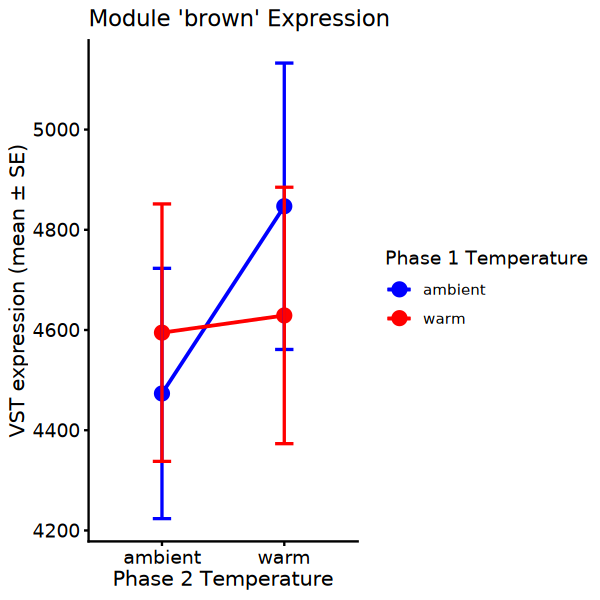

In [106]:
options(repr.plot.width = 5, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- brown_genes_vst %>%
  group_by(Phase1_temp, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# color of points
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'brown' Expression", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

# I STOPPED HERE

in the midnightblue module, phase 1 temperature is correlated with expression of these genes - phase 1 warming is lower than phase 1 ambient temps, regardless of any DO treatment, and regardless of a second (more recent) temperature treatment

taking a closer look at this - splitting apart the samples by DO treatments

In [107]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- midnightblue_vst %>%
  group_by(Phase1_temp, Phase2_temp, Phase1_DO, Phase2_DO) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_grid(Phase1_DO ~ Phase2_DO,
           labeller = labeller(
             Phase1_DO = label_both, 
             Phase2_DO = label_both
           )) + # rows ~ columns
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'midnightblue' Expression", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size = 11)
  )

ERROR: Error in eval(expr, envir, enclos): object 'midnightblue_vst' not found


when phase 2 DO is hypoxic, we see this shift in expression for the phase 1 warming

when phase 1 DO is hypoxic, phase 1 warming changes depending on the second temperature treatment (increases in warming)

when phase 1 DO is normoxic, phase 1 warming decreases in phase 2 warming

looking at this in another, different way - taking a step back and looking at phase 1 and phase 2 treatments as a whole, facetted by phase 1 temperature)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- midnightblue_vst %>%
  group_by(Phase1_treatment, Phase2_treatment, Phase1_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_treatment, y = meanExp, group = Phase1_treatment, color = Phase1_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase1_temp, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'midnightblue' Expression", 
    x = "Phase 2 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )

so it looks like what's driving warming to be lower is BH and WB treatments - both of these are phase 1 temp = warm, phase 2 DO = hypoxia